# KAMA-MSR Model Comparison and Analysis

This notebook loads multiple KAMA-MSR models, compares their characteristics, and identifies potential areas for improvement.

## 1. Import Required Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import skew, kurtosis
import pickle
import os
from typing import Dict, List, Tuple
from datetime import datetime
import warnings

# Styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.precision', 4)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load All Models from Directory

In [43]:
def load_all_models(sub_folder: str, edte_sub_folder: str, n_regimes: int = 2) -> Dict:
    """
    Load all KAMA-MSR models from a specified directory.
    
    Parameters:
    -----------
    sub_folder : str
        Asset type subfolder (e.g., 'us_equity', 'international_index')
    edte_sub_folder : str
        End date subfolder (e.g., '20220101')
    n_regimes : int
        Number of MSR regimes (used to construct filename)
    
    Returns:
    --------
    Dict : Dictionary with asset names as keys and loaded models as values
    """
    models = {}
    model_dir = f'saved_models/KAMA_MSR/{sub_folder}/{edte_sub_folder}'
    
    if not os.path.exists(model_dir):
        print(f"❌ Directory not found: {model_dir}")
        return models
    
    print(f"Loading models from: {model_dir}\n")
    
    # Get all pickle files
    pkl_files = [f for f in os.listdir(model_dir) if f.endswith('.pkl') and f != 'metadata.pkl']
    
    for filename in pkl_files:
        filepath = os.path.join(model_dir, filename)
        
        try:
            with open(filepath, 'rb') as f:
                model = pickle.load(f)
            
            # Extract asset name from filename
            # Format: AssetName_KAMA-MSR_X-regimes.pkl
            asset_name = filename.replace('_KAMA-MSR_', '|||').split('|||')[0]
            asset_name = asset_name.replace('_', ' ')
            
            models[asset_name] = model
            # print(f"✓ Loaded: {asset_name}")
            
        except Exception as e:
            print(f"❌ Error loading {filename}: {str(e)}")
    
    print(f"\n{'='*80}")
    print(f"Successfully loaded {len(models)} models")
    print(f"{'='*80}\n")
    
    return models

def get_available_model_folders() -> pd.DataFrame:
    """
    Scan the saved_models directory to show available model configurations.
    
    Returns:
    --------
    pd.DataFrame : Summary of available model folders
    """
    base_dir = 'saved_models/KAMA_MSR'
    
    if not os.path.exists(base_dir):
        print(f"❌ Base directory not found: {base_dir}")
        return pd.DataFrame()
    
    folders = []
    
    for asset_type in os.listdir(base_dir):
        asset_type_path = os.path.join(base_dir, asset_type)
        
        if not os.path.isdir(asset_type_path):
            continue
            
        for date_folder in os.listdir(asset_type_path):
            date_folder_path = os.path.join(asset_type_path, date_folder)
            
            if not os.path.isdir(date_folder_path):
                continue
            
            # Count models
            pkl_files = [f for f in os.listdir(date_folder_path) 
                        if f.endswith('.pkl') and f != 'metadata.pkl']
            
            if pkl_files:
                folders.append({
                    'Asset Type': asset_type,
                    'End Date': date_folder,
                    'N Models': len(pkl_files),
                    'Path': f"{asset_type}/{date_folder}"
                })
    
    df = pd.DataFrame(folders)
    return df.sort_values(['Asset Type', 'End Date']) if not df.empty else df

In [44]:
# Display available model configurations
available_models = get_available_model_folders()
print("Available Model Configurations:")
print("="*80)
if not available_models.empty:
    display(available_models)
else:
    print("No models found!")

Available Model Configurations:


,Asset Type,End Date,N Models,Path
4,commodity,20190101,16,commodity/20190101
5,commodity,20220101,12,commodity/20220101
2,int_equity,20190101,8,int_equity/20190101
3,int_equity,20220101,8,int_equity/20220101
0,us_equity,20190101,21,us_equity/20190101
1,us_equity,20220101,26,us_equity/20220101
6,us_treasury,20190101,3,us_treasury/20190101
7,us_treasury,20220101,3,us_treasury/20220101


In [45]:
# Load models - ADJUST THESE PARAMETERS
# sub_folder = 'us_equity'  # Change to your asset type
edte_sub_folder = '20190101'  # Change to your date
n_regimes = 2

models_universe = load_all_models('universe', edte_sub_folder, n_regimes)
models_us_equity = load_all_models('us_equity', edte_sub_folder, n_regimes)
models_commodity = load_all_models('commodity', edte_sub_folder, n_regimes)
models_int_equity = load_all_models('int_equity', edte_sub_folder, n_regimes)

# remove indices from models - only use ETFs
models_us_equity = {k: v for k, v in models_us_equity.items() if k not in['S&P 500', 'Dow Jones Industrial Average', 'Nasdaq Composite', 'Nasdaq 100', 'Russell 2000']}

# if models:
#     print(f"\nLoaded models for assets:")
#     for i, asset_name in enumerate(models.keys(), 1):
#         print(f"  {i:2d}. {asset_name}")

models = {**models_us_equity, **models_commodity, **models_int_equity}

❌ Directory not found: saved_models/KAMA_MSR/universe/20190101
Loading models from: saved_models/KAMA_MSR/us_equity/20190101




Successfully loaded 21 models

Loading models from: saved_models/KAMA_MSR/commodity/20190101


Successfully loaded 16 models

Loading models from: saved_models/KAMA_MSR/int_equity/20190101


Successfully loaded 8 models



## 3. Extract Model Metadata and Parameters

In [46]:
def extract_model_metadata(models: Dict) -> pd.DataFrame:
    """
    Extract comprehensive metadata from all loaded models.
    
    Parameters:
    -----------
    models : Dict
        Dictionary of loaded KAMA-MSR models
    
    Returns:
    --------
    pd.DataFrame : Comprehensive metadata for all models
    """
    metadata = []
    
    for asset_name, model in models.items():
        try:
            # Basic info
            n_data_points = len(model.prices) if model.prices is not None else 0
            n_regimes_msr = model.msr.n_regimes
            n_combined_regimes = model.n_combined_regimes
            
            # KAMA parameters
            kama_n = model.kama.n
            kama_n_fast = model.kama.n_fast
            kama_n_slow = model.kama.n_slow
            gamma = model.gamma
            
            # Regime labels
            regime_labels = model.regime_labels.dropna()
            n_regime_changes = (regime_labels.diff() != 0).sum()
            
            # Regime distribution
            regime_counts = regime_labels.value_counts()
            regime_pcts = regime_counts / len(regime_labels) * 100
            
            # MSR parameters
            msr_means = model.msr.means
            msr_stds = model.msr.stds
            msr_betas = model.msr.betas
            
            # Build metadata dict
            meta = {
                'Asset': asset_name,
                'N_Data_Points': n_data_points,
                'N_MSR_Regimes': n_regimes_msr,
                'N_Combined_Regimes': n_combined_regimes,
                'KAMA_n': kama_n,
                'KAMA_n_fast': kama_n_fast,
                'KAMA_n_slow': kama_n_slow,
                'Filter_gamma': gamma,
                'N_Regime_Changes': n_regime_changes,
                'Avg_Regime_Duration': len(regime_labels) / (n_regime_changes + 1),
            }
            
            # Add regime-specific data
            for i in range(n_combined_regimes):
                meta[f'Regime_{i}_Pct'] = regime_pcts.get(i, 0)
                meta[f'Regime_{i}_Count'] = regime_counts.get(i, 0)
            
            # Add MSR parameters
            for i in range(n_regimes_msr):
                meta[f'MSR_Mean_{i}'] = msr_means[i]
                meta[f'MSR_Std_{i}'] = msr_stds[i]
                meta[f'MSR_Beta_{i}'] = msr_betas[i]
            
            # Add transition probabilities
            for i in range(n_regimes_msr):
                for j in range(n_regimes_msr):
                    meta[f'Trans_P_{i}_to_{j}'] = model.msr.transition_probs[i, j]
            
            metadata.append(meta)
            
        except Exception as e:
            print(f"❌ Error extracting metadata for {asset_name}: {str(e)}")
    
    df = pd.DataFrame(metadata)
    return df

# Extract metadata
metadata_df = extract_model_metadata(models)

print("\nModel Metadata Summary:")
print("="*80)
display(metadata_df.head())

print(f"\nShape: {metadata_df.shape}")
print(f"Columns: {list(metadata_df.columns)}")


Model Metadata Summary:


,Asset,N_Data_Points,N_MSR_Regimes,N_Combined_Regimes,KAMA_n,KAMA_n_fast,KAMA_n_slow,Filter_gamma,N_Regime_Changes,Avg_Regime_Duration,Regime_0_Pct,Regime_0_Count,Regime_1_Pct,Regime_1_Count,Regime_2_Pct,Regime_2_Count,Regime_3_Pct,Regime_3_Count,MSR_Mean_0,MSR_Std_0,MSR_Beta_0,MSR_Mean_1,MSR_Std_1,MSR_Beta_1,Trans_P_0_to_0,Trans_P_0_to_1,Trans_P_1_to_0,Trans_P_1_to_1
0,Consumer Discretionary Select Sector SPDR,5038,2,4,20,12,38,1.35,62,79.6349,73.0915,3667,19.0951,958,0.7973,40,7.0161,352,0.0004,0.0129,-0.0052,-0.0008,0.0379,-0.0003,0.9927,0.0073,0.0778,0.9222
1,Consumer Staples Select Sector SPDR,5038,2,4,21,10,40,0.40,60,82.2295,70.0558,3514,28.8876,1449,0.0598,3,0.9968,50,0.0002,0.0107,-0.0169,-0.0020,0.0584,0.0013,0.9944,0.0056,0.2877,0.7123
2,iShares Micro-Cap ETF,3367,2,4,15,12,43,0.50,43,76.1591,65.5625,2197,27.5440,923,0.7759,26,6.1176,205,0.0004,0.0142,-0.0012,-0.0028,0.0461,-0.0353,0.9952,0.0048,0.0607,0.9393
3,Invesco S&P 500 Equal Weight ETF,3946,2,4,14,10,44,1.50,29,131.0333,79.4454,3123,13.4317,528,0.8140,32,6.3088,248,0.0005,0.0118,-0.0033,-0.0018,0.0419,-0.0224,0.9958,0.0042,0.0532,0.9468
4,iShares Russell 2000 ETF,4678,2,4,14,12,44,0.85,52,87.9811,69.9121,3260,22.9037,1068,0.7506,35,6.4336,300,0.0004,0.0137,-0.0107,-0.0020,0.0415,-0.0342,0.9954,0.0046,0.0583,0.9417



Shape: (45, 28)
Columns: ['Asset', 'N_Data_Points', 'N_MSR_Regimes', 'N_Combined_Regimes', 'KAMA_n', 'KAMA_n_fast', 'KAMA_n_slow', 'Filter_gamma', 'N_Regime_Changes', 'Avg_Regime_Duration', 'Regime_0_Pct', 'Regime_0_Count', 'Regime_1_Pct', 'Regime_1_Count', 'Regime_2_Pct', 'Regime_2_Count', 'Regime_3_Pct', 'Regime_3_Count', 'MSR_Mean_0', 'MSR_Std_0', 'MSR_Beta_0', 'MSR_Mean_1', 'MSR_Std_1', 'MSR_Beta_1', 'Trans_P_0_to_0', 'Trans_P_0_to_1', 'Trans_P_1_to_0', 'Trans_P_1_to_1']


## 4. Compare KAMA Parameters Across Assets

In [47]:
# Summary statistics for KAMA parameters
kama_cols = ['KAMA_n', 'KAMA_n_fast', 'KAMA_n_slow', 'Filter_gamma']
kama_summary = metadata_df[['Asset'] + kama_cols].describe()

print("KAMA Parameter Summary Statistics:")
print("="*80)
display(kama_summary)

# Identify unique parameter combinations
unique_kama = metadata_df[kama_cols].drop_duplicates()
print(f"\nNumber of unique KAMA parameter combinations: {len(unique_kama)}")
print("\nUnique KAMA configurations:")
display(unique_kama)

KAMA Parameter Summary Statistics:


,KAMA_n,KAMA_n_fast,KAMA_n_slow,Filter_gamma
count,45.0000,45.0000,45.0000,45.0000
mean,17.6889,9.8889,38.5556,0.9000
std,6.1858,3.1925,6.8707,0.3977
min,8.0000,2.0000,20.0000,0.3000
25%,13.0000,10.0000,34.0000,0.5500
50%,16.0000,12.0000,43.0000,0.8500
75%,25.0000,12.0000,44.0000,1.3000
max,26.0000,12.0000,45.0000,1.6000



Number of unique KAMA parameter combinations: 44

Unique KAMA configurations:


,KAMA_n,KAMA_n_fast,KAMA_n_slow,Filter_gamma
0,20,12,38,1.35
1,21,10,40,0.40
2,15,12,43,0.50
3,14,10,44,1.50
4,14,12,44,0.85
5,10,12,44,1.40
6,25,10,43,0.75
7,24,12,45,1.50
8,10,10,35,1.35
9,13,10,35,0.90


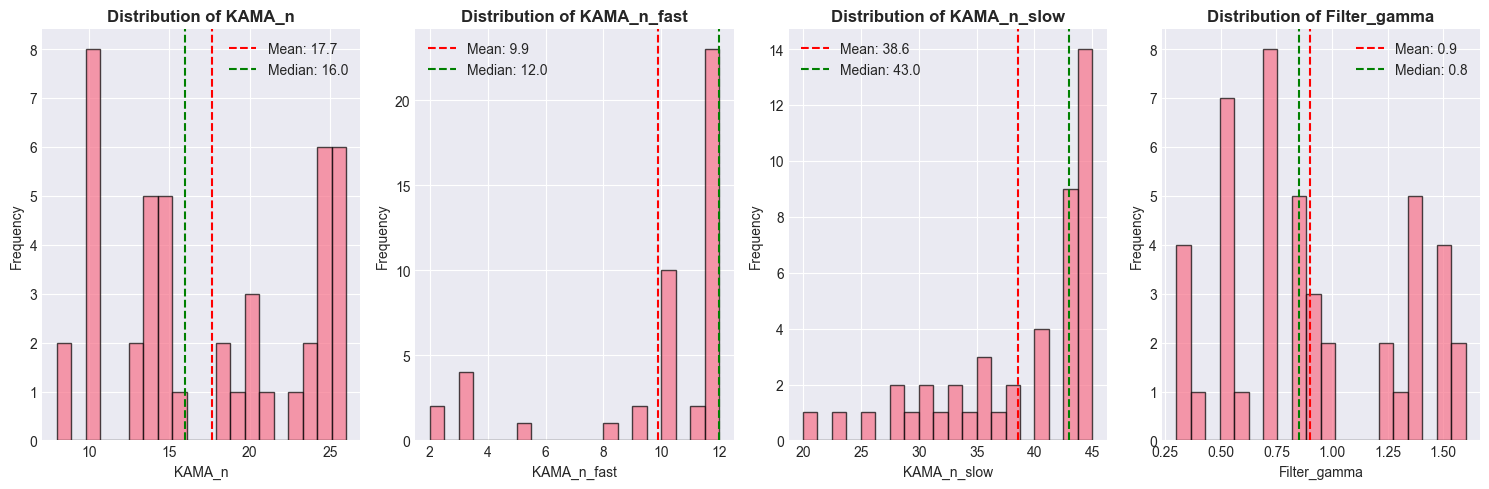

In [48]:
# Visualize KAMA parameters
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for idx, col in enumerate(kama_cols):
    ax = axes[idx]
    metadata_df[col].hist(bins=20, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.axvline(metadata_df[col].mean(), color='red', linestyle='--', 
               label=f'Mean: {metadata_df[col].mean():.1f}')
    ax.axvline(metadata_df[col].median(), color='green', linestyle='--', 
               label=f'Median: {metadata_df[col].median():.1f}')
    ax.legend()

plt.tight_layout()
plt.show()

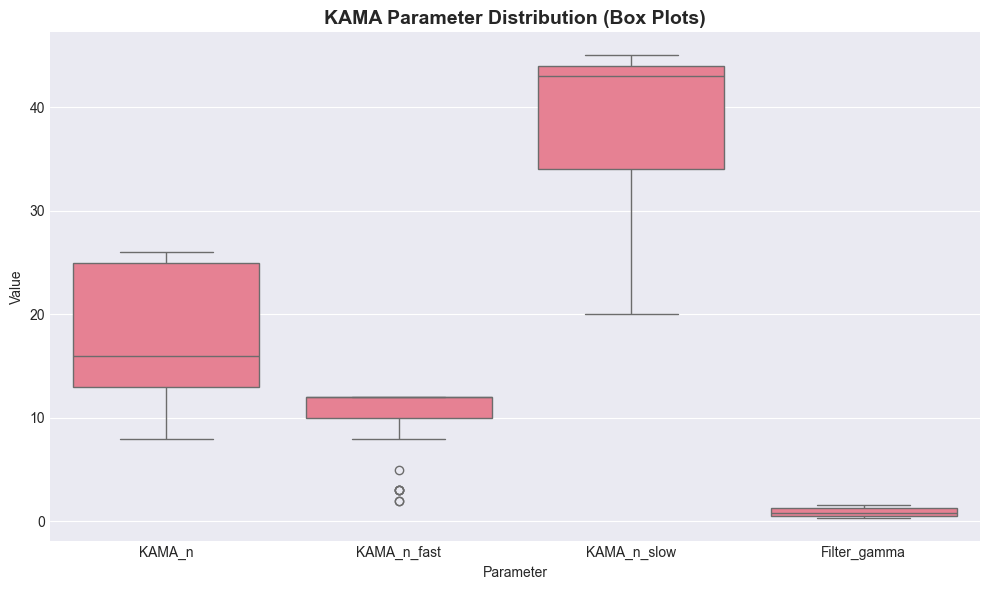


KAMA Parameter Outliers (values > 1.5 IQR):

KAMA_n_fast:
  Live Cattle Futures: 2
  Coffee: 3
  US Dollar: 5
  Corn Futures: 2
  Aluminum Futures: 3
  Vanguard Total International Stock ETF: 3
  Vanguard FTSE Europe ETF: 3


In [49]:
# Box plots for KAMA parameters
fig, ax = plt.subplots(figsize=(10, 6))

kama_data = metadata_df[kama_cols].melt(var_name='Parameter', value_name='Value')
sns.boxplot(data=kama_data, x='Parameter', y='Value', ax=ax)
ax.set_title('KAMA Parameter Distribution (Box Plots)', fontsize=14, fontweight='bold')
ax.set_ylabel('Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Identify outliers
print("\nKAMA Parameter Outliers (values > 1.5 IQR):")
print("="*80)
for col in kama_cols:
    Q1 = metadata_df[col].quantile(0.25)
    Q3 = metadata_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = metadata_df[(metadata_df[col] < Q1 - 1.5*IQR) | (metadata_df[col] > Q3 + 1.5*IQR)]
    if len(outliers) > 0:
        print(f"\n{col}:")
        for _, row in outliers.iterrows():
            print(f"  {row['Asset']}: {row[col]}")

## 5. Compare MSR Parameters Across Assets

In [50]:
# Extract MSR parameter columns
msr_mean_cols = [col for col in metadata_df.columns if col.startswith('MSR_Mean_')]
msr_std_cols = [col for col in metadata_df.columns if col.startswith('MSR_Std_')]
msr_beta_cols = [col for col in metadata_df.columns if col.startswith('MSR_Beta_')]

print("MSR Parameter Summary Statistics:")
print("="*80)

print("\nMSR Means:")
display(metadata_df[['Asset'] + msr_mean_cols].describe())

print("\nMSR Standard Deviations:")
display(metadata_df[['Asset'] + msr_std_cols].describe())

print("\nMSR Betas:")
display(metadata_df[['Asset'] + msr_beta_cols].describe())

MSR Parameter Summary Statistics:

MSR Means:


,MSR_Mean_0,MSR_Mean_1
count,45.0000,45.0000
mean,0.0006,-0.0018
std,0.0033,0.0032
min,-0.0109,-0.0090
25%,0.0002,-0.0031
50%,0.0004,-0.0020
75%,0.0004,-0.0006
max,0.0170,0.0110



MSR Standard Deviations:


,MSR_Std_0,MSR_Std_1
count,45.0000,45.0000
mean,0.0329,0.0465
std,0.0612,0.0165
min,0.0107,0.0085
25%,0.0126,0.0389
50%,0.0140,0.0444
75%,0.0167,0.0533
max,0.2696,0.0955



MSR Betas:


,MSR_Beta_0,MSR_Beta_1
count,45.0000,45.0000
mean,-0.0070,-0.0409
std,0.0171,0.0826
min,-0.0432,-0.4431
25%,-0.0157,-0.0454
50%,-0.0098,-0.0226
75%,-0.0025,-0.0040
max,0.0527,0.0227


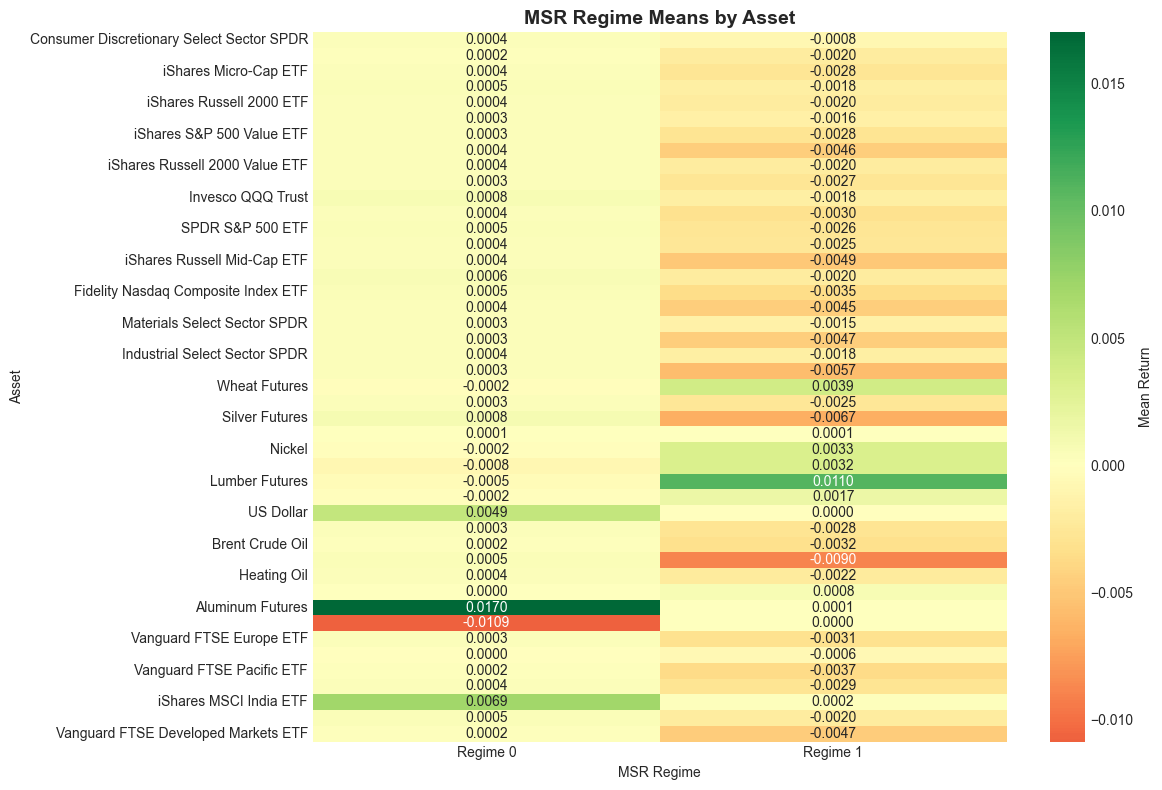

In [51]:
# Heatmap of MSR means
plt.figure(figsize=(12, 8))

msr_means_data = metadata_df[['Asset'] + msr_mean_cols].set_index('Asset')
msr_means_data.columns = [col.replace('MSR_Mean_', 'Regime ') for col in msr_means_data.columns]

sns.heatmap(msr_means_data, annot=True, fmt='.4f', cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'Mean Return'})
plt.title('MSR Regime Means by Asset', fontsize=14, fontweight='bold')
plt.ylabel('Asset')
plt.xlabel('MSR Regime')
plt.tight_layout()
plt.show()

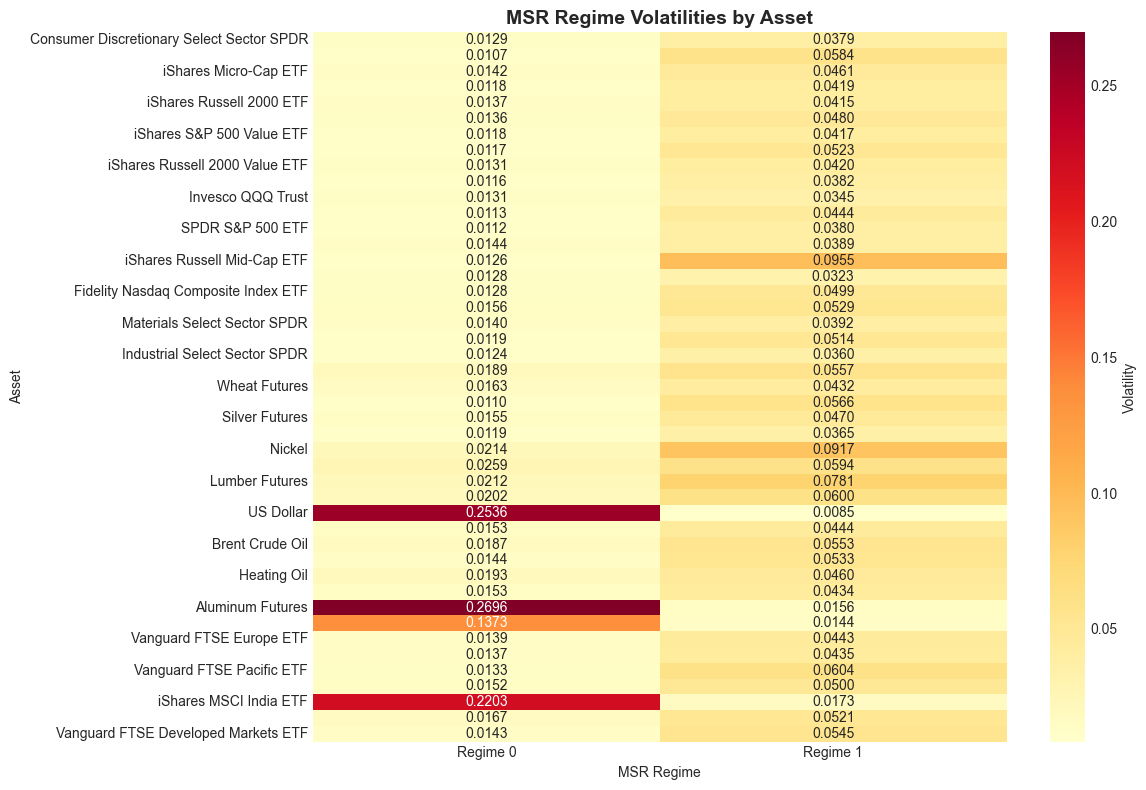

In [52]:
# Heatmap of MSR volatilities
plt.figure(figsize=(12, 8))

msr_stds_data = metadata_df[['Asset'] + msr_std_cols].set_index('Asset')
msr_stds_data.columns = [col.replace('MSR_Std_', 'Regime ') for col in msr_stds_data.columns]

sns.heatmap(msr_stds_data, annot=True, fmt='.4f', cmap='YlOrRd', 
            cbar_kws={'label': 'Volatility'})
plt.title('MSR Regime Volatilities by Asset', fontsize=14, fontweight='bold')
plt.ylabel('Asset')
plt.xlabel('MSR Regime')
plt.tight_layout()
plt.show()

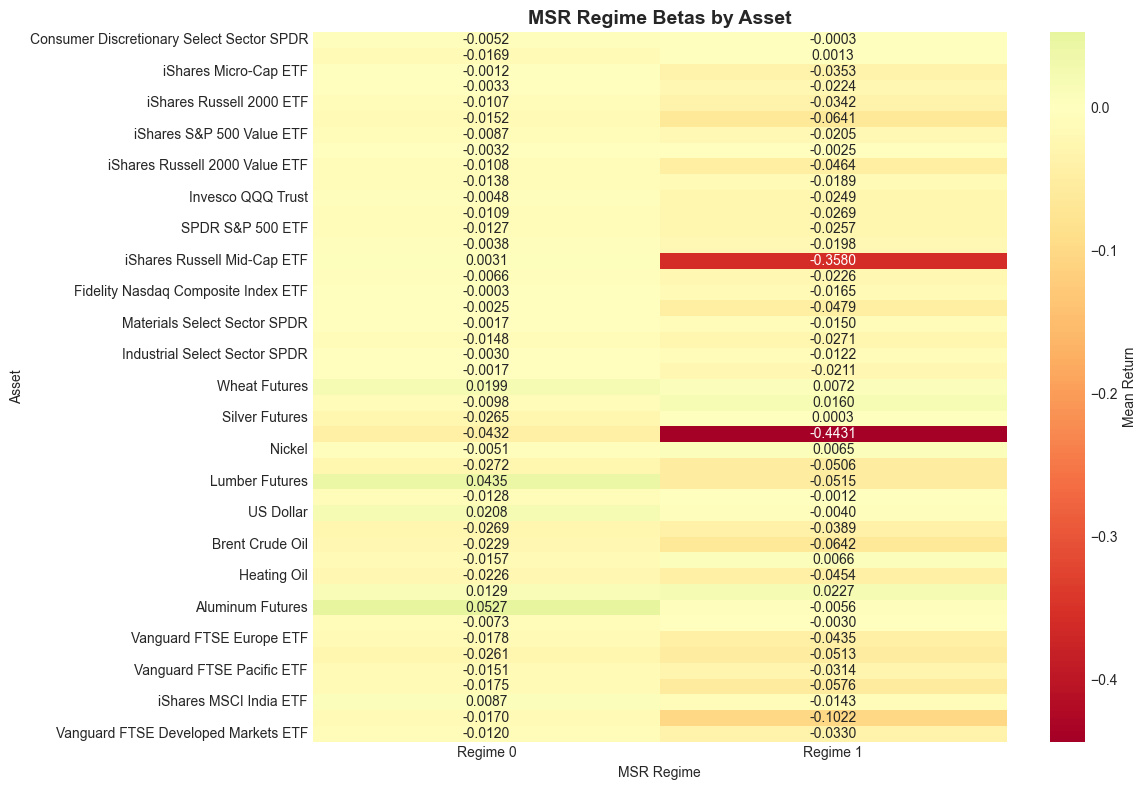

In [53]:
# Heatmap of MSR betas
plt.figure(figsize=(12, 8))

msr_betas_data = metadata_df[['Asset'] + msr_beta_cols].set_index('Asset')
msr_betas_data.columns = [col.replace('MSR_Beta_', 'Regime ') for col in msr_betas_data.columns]

sns.heatmap(msr_betas_data, annot=True, fmt='.4f', cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'Mean Return'})
plt.title('MSR Regime Betas by Asset', fontsize=14, fontweight='bold')
plt.ylabel('Asset')
plt.xlabel('MSR Regime')
plt.tight_layout()
plt.show()

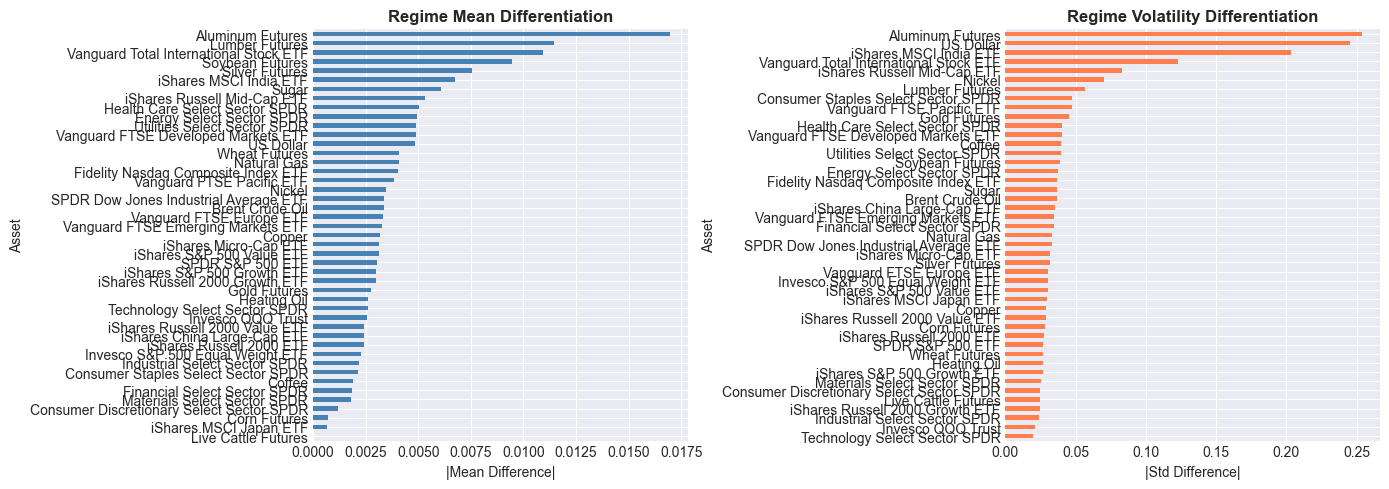


Assets with WEAK Regime Differentiation:

Lowest Mean Differentiation:


,Asset,Mean_Diff,MSR_Mean_0,MSR_Mean_1
25,Live Cattle Futures,1.9951e-05,1.0606e-04,8.6107e-05
39,iShares MSCI Japan ETF,6.5106e-04,1.1725e-05,-6.3934e-04
35,Corn Futures,7.2972e-04,3.1676e-05,7.6139e-04
0,Consumer Discretionary Select Sector SPDR,1.1994e-03,3.7347e-04,-8.2592e-04
18,Materials Select Sector SPDR,1.8174e-03,3.2919e-04,-1.4882e-03



Lowest Volatility Differentiation:


,Asset,Std_Diff,MSR_Std_0,MSR_Std_1
15,Technology Select Sector SPDR,0.0195,0.0128,0.0323
10,Invesco QQQ Trust,0.0214,0.0131,0.0345
20,Industrial Select Sector SPDR,0.0236,0.0124,0.0360
13,iShares Russell 2000 Growth ETF,0.0244,0.0144,0.0389
25,Live Cattle Futures,0.0246,0.0119,0.0365


In [54]:
# Compare regime differentiation (difference between regimes)
if len(msr_mean_cols) == 2:
    metadata_df['Mean_Diff'] = abs(metadata_df['MSR_Mean_0'] - metadata_df['MSR_Mean_1'])
    metadata_df['Std_Diff'] = abs(metadata_df['MSR_Std_0'] - metadata_df['MSR_Std_1'])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Mean difference
    metadata_df.sort_values('Mean_Diff').plot.barh(x='Asset', y='Mean_Diff', ax=axes[0], 
                                                     color='steelblue', legend=False)
    axes[0].set_title('Regime Mean Differentiation', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('|Mean Difference|')
    
    # Std difference
    metadata_df.sort_values('Std_Diff').plot.barh(x='Asset', y='Std_Diff', ax=axes[1], 
                                                    color='coral', legend=False)
    axes[1].set_title('Regime Volatility Differentiation', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('|Std Difference|')
    
    plt.tight_layout()
    plt.show()
    
    print("\nAssets with WEAK Regime Differentiation:")
    print("="*80)
    print("\nLowest Mean Differentiation:")
    display(metadata_df.nsmallest(5, 'Mean_Diff')[['Asset', 'Mean_Diff', 'MSR_Mean_0', 'MSR_Mean_1']])
    
    print("\nLowest Volatility Differentiation:")
    display(metadata_df.nsmallest(5, 'Std_Diff')[['Asset', 'Std_Diff', 'MSR_Std_0', 'MSR_Std_1']])

## 6. Regime Distribution Analysis

In [55]:
# Regime distribution summary
regime_pct_cols = [col for col in metadata_df.columns if col.startswith('Regime_') and col.endswith('_Pct')]

print("Regime Distribution Summary:")
print("="*80)
display(metadata_df[['Asset'] + regime_pct_cols].describe())

# Identify imbalanced regimes
print("\nAssets with Imbalanced Regime Distributions:")
print("="*80)

for _, row in metadata_df.iterrows():
    pcts = [row[col] for col in regime_pct_cols]
    max_pct = max(pcts)
    min_pct = min(pcts)
    
    if max_pct > 70:  # One regime dominates
        print(f"\n{row['Asset']}:")
        for i, col in enumerate(regime_pct_cols):
            print(f"  Regime {i}: {row[col]:.1f}%")

Regime Distribution Summary:


,Regime_0_Pct,Regime_1_Pct,Regime_2_Pct,Regime_3_Pct
count,45.0000,45.0000,45.0000,45.0000
mean,52.6683,32.4444,6.0481,8.8392
std,22.4382,18.8486,15.5673,12.1803
min,0.0000,0.0000,0.0000,0.1024
25%,42.7465,20.3499,0.1286,2.7296
50%,58.0943,28.8876,0.7973,6.1176
75%,68.5812,44.3629,2.3244,7.5607
max,79.4454,81.9767,63.7069,54.3624



Assets with Imbalanced Regime Distributions:

Consumer Discretionary Select Sector SPDR:
  Regime 0: 73.1%
  Regime 1: 19.1%
  Regime 2: 0.8%
  Regime 3: 7.0%

Consumer Staples Select Sector SPDR:
  Regime 0: 70.1%
  Regime 1: 28.9%
  Regime 2: 0.1%
  Regime 3: 1.0%

Invesco S&P 500 Equal Weight ETF:
  Regime 0: 79.4%
  Regime 1: 13.4%
  Regime 2: 0.8%
  Regime 3: 6.3%

Health Care Select Sector SPDR:
  Regime 0: 74.9%
  Regime 1: 23.2%
  Regime 2: 0.1%
  Regime 3: 1.8%

iShares Russell 2000 Value ETF:
  Regime 0: 70.5%
  Regime 1: 22.1%
  Regime 2: 0.8%
  Regime 3: 6.6%

SPDR Dow Jones Industrial Average ETF:
  Regime 0: 76.1%
  Regime 1: 20.3%
  Regime 2: 0.1%
  Regime 3: 3.5%

SPDR S&P 500 ETF:
  Regime 0: 75.7%
  Regime 1: 18.9%
  Regime 2: 0.4%
  Regime 3: 5.0%

iShares Russell Mid-Cap ETF:
  Regime 0: 75.1%
  Regime 1: 22.3%
  Regime 2: 0.0%
  Regime 3: 2.6%

Fidelity Nasdaq Composite Index ETF:
  Regime 0: 79.0%
  Regime 1: 17.8%
  Regime 2: 0.0%
  Regime 3: 3.2%

Industrial Se

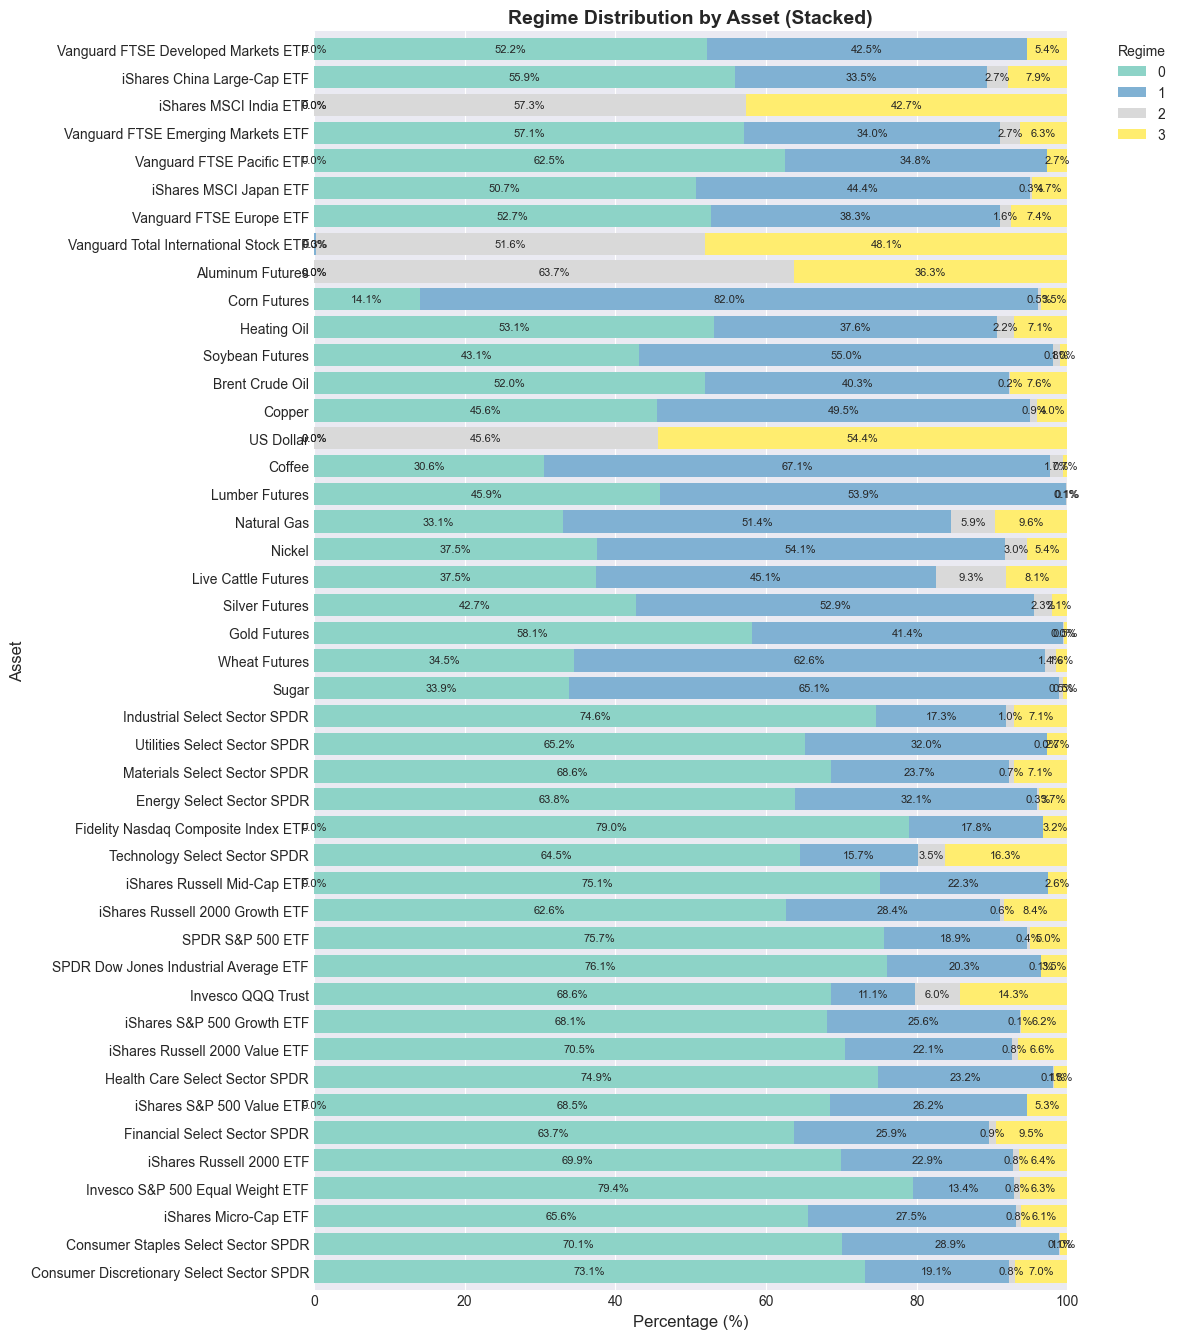

In [56]:
# Stacked bar chart of regime distributions
regime_pct_data = metadata_df[['Asset'] + regime_pct_cols].set_index('Asset')
regime_pct_data.columns = [col.replace('Regime_', '').replace('_Pct', '') for col in regime_pct_data.columns]

ax = regime_pct_data.plot.barh(stacked=True, figsize=(12, max(8, len(models)*0.3)), 
                                colormap='Set3', width=0.8)
ax.set_xlabel('Percentage (%)', fontsize=12)
ax.set_ylabel('Asset', fontsize=12)
ax.set_title('Regime Distribution by Asset (Stacked)', fontsize=14, fontweight='bold')
ax.legend(title='Regime', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlim(0, 100)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)

plt.tight_layout()
plt.show()

Regime Diversity Scores:
(0 = Perfectly balanced, 1 = Completely concentrated)



,Asset,Regime_Diversity_Score,Regime_0_Pct,Regime_1_Pct,Regime_2_Pct,Regime_3_Pct
35,Corn Futures,0.5811,14.0864,81.9767,0.4651,3.4718
16,Fidelity Nasdaq Composite Index ETF,0.5644,79.0010,17.7824,0.0000,3.2165
7,Health Care Select Sector SPDR,0.5418,74.8853,23.2196,0.1197,1.7754
14,iShares Russell Mid-Cap ETF,0.5348,75.1201,22.2502,0.0000,2.6298
11,SPDR Dow Jones Industrial Average ETF,0.5276,76.0936,20.3499,0.0951,3.4614
36,Aluminum Futures,0.5275,0.0000,0.0000,63.7069,36.2931
1,Consumer Staples Select Sector SPDR,0.5251,70.0558,28.8876,0.0598,0.9968
3,Invesco S&P 500 Equal Weight ETF,0.5196,79.4454,13.4317,0.8140,6.3088
42,iShares MSCI India ETF,0.5077,0.0000,0.0000,57.3014,42.6986
30,US Dollar,0.5027,0.0000,0.0000,45.6376,54.3624


<Figure size 1000x1350 with 0 Axes>

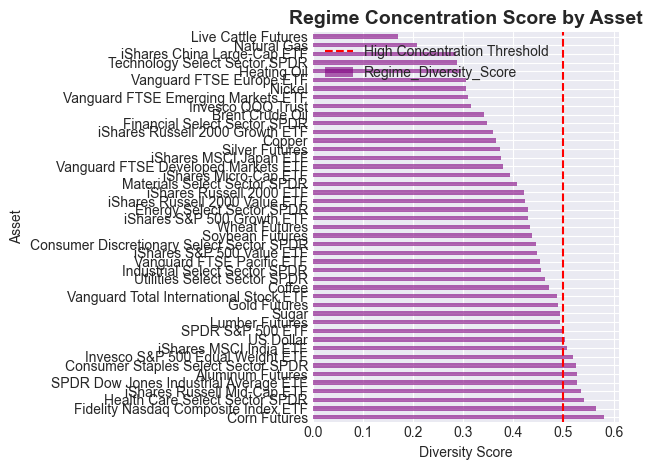

In [57]:
# Regime diversity metric (entropy-based)
from scipy.stats import entropy

def regime_diversity_score(pcts):
    """Calculate normalized entropy as diversity score (0=uniform, 1=concentrated)"""
    pcts_normalized = np.array(pcts) / 100.0
    max_entropy = np.log(len(pcts))
    return 1 - (entropy(pcts_normalized) / max_entropy) if max_entropy > 0 else 0

metadata_df['Regime_Diversity_Score'] = metadata_df.apply(
    lambda row: regime_diversity_score([row[col] for col in regime_pct_cols]), axis=1
)

print("Regime Diversity Scores:")
print("="*80)
print("(0 = Perfectly balanced, 1 = Completely concentrated)\n")

diversity_sorted = metadata_df[['Asset', 'Regime_Diversity_Score'] + regime_pct_cols].sort_values('Regime_Diversity_Score', ascending=False)
display(diversity_sorted)

# Visualize
plt.figure(figsize=(10, max(6, len(models)*0.3)))
diversity_sorted.plot.barh(x='Asset', y='Regime_Diversity_Score', 
                           color='purple', alpha=0.6, legend=False)
plt.axvline(0.5, color='red', linestyle='--', label='High Concentration Threshold')
plt.xlabel('Diversity Score')
plt.ylabel('Asset')
plt.title('Regime Concentration Score by Asset', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Regime Duration Analysis

In [58]:
def extract_regime_duration_stats(models: Dict) -> pd.DataFrame:
    """
    Extract regime duration statistics from all models.
    
    Parameters:
    -----------
    models : Dict
        Dictionary of loaded KAMA-MSR models
    
    Returns:
    --------
    pd.DataFrame : Regime duration statistics for all models
    """
    duration_stats = []
    
    for asset_name, model in models.items():
        try:
            regime_labels = model.regime_labels.dropna()
            
            # Calculate regime durations
            regime_changes = regime_labels != regime_labels.shift(1)
            regime_blocks = regime_changes.cumsum()
            
            durations = regime_labels.groupby(regime_blocks).size()
            
            stats = {
                'Asset': asset_name,
                'Mean_Duration': durations.mean(),
                'Median_Duration': durations.median(),
                'Std_Duration': durations.std(),
                'Min_Duration': durations.min(),
                'Max_Duration': durations.max(),
                'Q25_Duration': durations.quantile(0.25),
                'Q75_Duration': durations.quantile(0.75),
                'N_Regimes': len(durations),
                'Pct_Single_Period': (durations == 1).sum() / len(durations) * 100
            }
            
            duration_stats.append(stats)
            
        except Exception as e:
            print(f"❌ Error extracting duration stats for {asset_name}: {str(e)}")
    
    return pd.DataFrame(duration_stats)

duration_df = extract_regime_duration_stats(models)

print("Regime Duration Statistics:")
print("="*80)
display(duration_df.sort_values('Mean_Duration', ascending=False))

Regime Duration Statistics:


,Asset,Mean_Duration,Median_Duration,Std_Duration,Min_Duration,Max_Duration,Q25_Duration,Q75_Duration,N_Regimes,Pct_Single_Period
23,Gold Futures,151.6250,31.0,324.5200,2,1656,12.25,98.25,40,0.0000
3,Invesco S&P 500 Equal Weight ETF,131.0000,36.0,235.8938,3,1066,13.25,161.00,30,0.0000
10,Invesco QQQ Trust,115.3721,34.0,187.6900,6,1000,14.00,143.00,43,0.0000
14,iShares Russell Mid-Cap ETF,109.3000,43.5,141.5019,1,572,16.75,156.00,40,2.5000
21,Sugar,108.8182,32.0,184.3935,1,995,8.50,97.00,55,5.4545
6,iShares S&P 500 Value ETF,108.1628,45.0,210.2445,5,1118,17.50,93.00,43,0.0000
7,Health Care Select Sector SPDR,106.6383,53.0,165.7934,1,957,17.50,119.00,47,2.1277
40,Vanguard FTSE Pacific ETF,104.5152,48.0,156.5360,3,606,12.00,96.00,33,0.0000
12,SPDR S&P 500 ETF,103.8276,24.5,184.5044,1,821,9.25,109.25,58,3.4483
42,iShares MSCI India ETF,100.6471,60.0,116.1857,6,412,27.00,143.00,17,0.0000


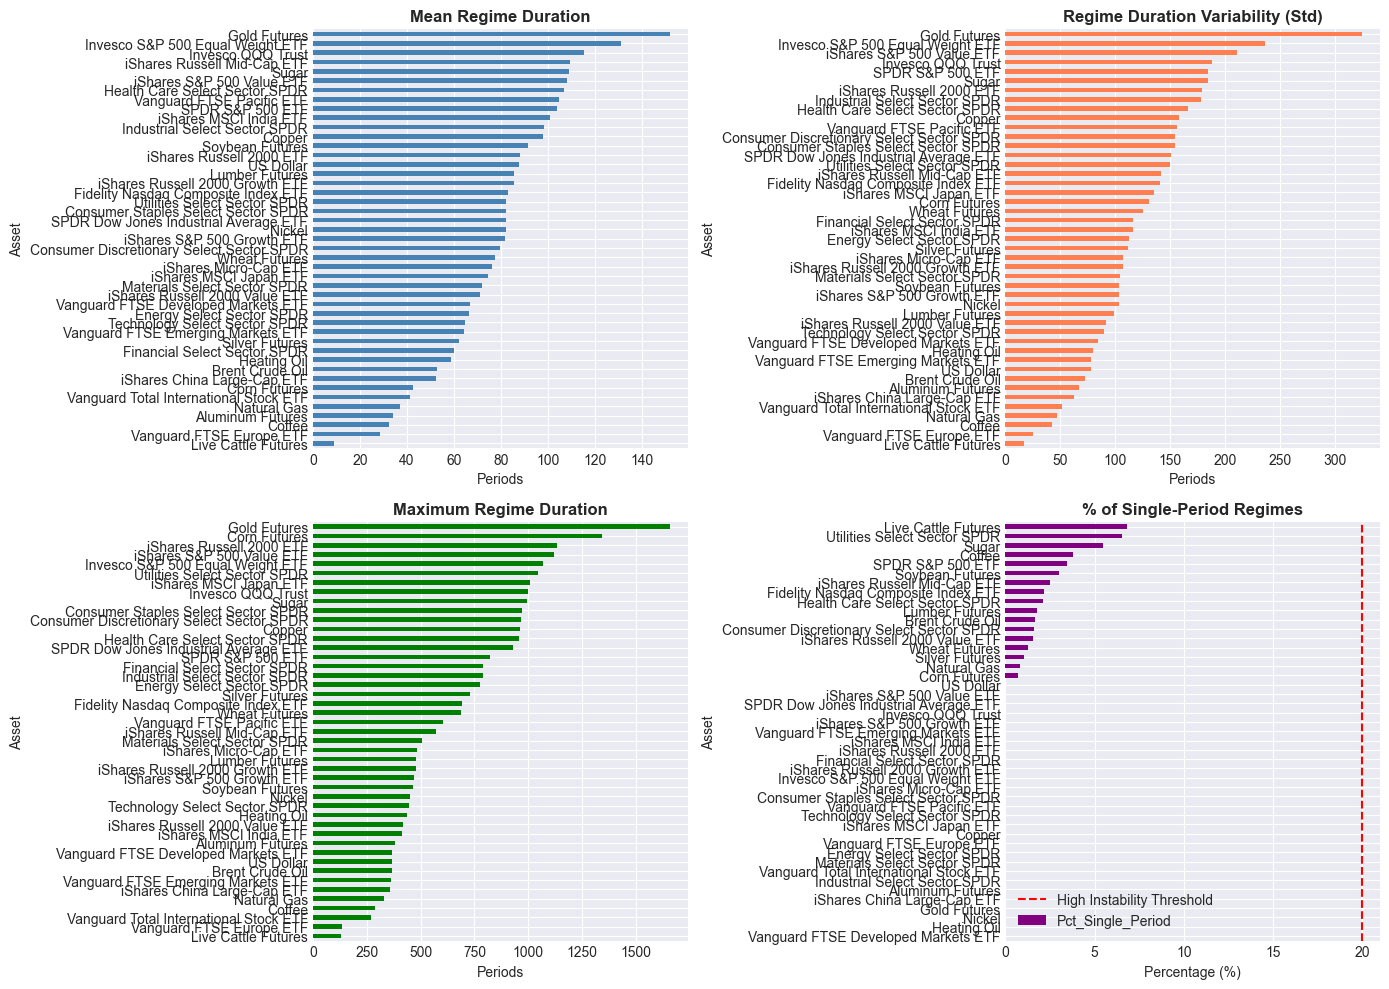

In [59]:
# Visualize regime duration characteristics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mean duration
duration_df.sort_values('Mean_Duration').plot.barh(x='Asset', y='Mean_Duration', 
                                                     ax=axes[0,0], color='steelblue', legend=False)
axes[0,0].set_title('Mean Regime Duration', fontweight='bold')
axes[0,0].set_xlabel('Periods')

# Duration variability (std)
duration_df.sort_values('Std_Duration').plot.barh(x='Asset', y='Std_Duration', 
                                                    ax=axes[0,1], color='coral', legend=False)
axes[0,1].set_title('Regime Duration Variability (Std)', fontweight='bold')
axes[0,1].set_xlabel('Periods')

# Max duration
duration_df.sort_values('Max_Duration').plot.barh(x='Asset', y='Max_Duration', 
                                                    ax=axes[1,0], color='green', legend=False)
axes[1,0].set_title('Maximum Regime Duration', fontweight='bold')
axes[1,0].set_xlabel('Periods')

# Percentage of single-period regimes
duration_df.sort_values('Pct_Single_Period').plot.barh(x='Asset', y='Pct_Single_Period', 
                                                         ax=axes[1,1], color='purple', legend=False)
axes[1,1].set_title('% of Single-Period Regimes', fontweight='bold')
axes[1,1].set_xlabel('Percentage (%)')
axes[1,1].axvline(20, color='red', linestyle='--', label='High Instability Threshold')
axes[1,1].legend()

plt.tight_layout()
plt.show()

In [60]:
# Identify problematic duration patterns
print("Assets with Regime Duration Issues:")
print("="*80)

print("\n1. HIGH REGIME INSTABILITY (>20% single-period regimes):")
unstable = duration_df[duration_df['Pct_Single_Period'] > 20].sort_values('Pct_Single_Period', ascending=False)
if len(unstable) > 0:
    display(unstable[['Asset', 'Pct_Single_Period', 'Mean_Duration', 'N_Regimes']])
else:
    print("  ✓ None found")

print("\n2. VERY SHORT AVERAGE DURATIONS (<5 periods):")
short_duration = duration_df[duration_df['Mean_Duration'] < 5].sort_values('Mean_Duration')
if len(short_duration) > 0:
    display(short_duration[['Asset', 'Mean_Duration', 'Median_Duration', 'Pct_Single_Period']])
else:
    print("  ✓ None found")

print("\n3. VERY LONG AVERAGE DURATIONS (>50 periods):")
long_duration = duration_df[duration_df['Mean_Duration'] > 50].sort_values('Mean_Duration', ascending=False)
if len(long_duration) > 0:
    display(long_duration[['Asset', 'Mean_Duration', 'Max_Duration', 'N_Regimes']])
else:
    print("  ✓ None found")

Assets with Regime Duration Issues:

1. HIGH REGIME INSTABILITY (>20% single-period regimes):
  ✓ None found

2. VERY SHORT AVERAGE DURATIONS (<5 periods):
  ✓ None found

3. VERY LONG AVERAGE DURATIONS (>50 periods):


,Asset,Mean_Duration,Max_Duration,N_Regimes
23,Gold Futures,151.6250,1656,40
3,Invesco S&P 500 Equal Weight ETF,131.0000,1066,30
10,Invesco QQQ Trust,115.3721,1000,43
14,iShares Russell Mid-Cap ETF,109.3000,572,40
21,Sugar,108.8182,995,55
6,iShares S&P 500 Value ETF,108.1628,1118,43
7,Health Care Select Sector SPDR,106.6383,957,47
40,Vanguard FTSE Pacific ETF,104.5152,606,33
12,SPDR S&P 500 ETF,103.8276,821,58
42,iShares MSCI India ETF,100.6471,412,17


## 8. Transition Probability Comparison

In [61]:
# Extract transition probability columns
trans_prob_cols = [col for col in metadata_df.columns if col.startswith('Trans_P_')]

print("Transition Probability Summary:")
print("="*80)
display(metadata_df[['Asset'] + trans_prob_cols].describe())

# Calculate average transition probabilities
print("\n\nAverage Transition Probabilities Across All Assets:")
avg_trans_probs = metadata_df[trans_prob_cols].mean()
for col in trans_prob_cols:
    from_regime = col.split('_')[2]
    to_regime = col.split('_')[4]
    print(f"  P({from_regime} → {to_regime}): {avg_trans_probs[col]:.4f}")

Transition Probability Summary:


,Trans_P_0_to_0,Trans_P_0_to_1,Trans_P_1_to_0,Trans_P_1_to_1
count,45.0000,45.0000,45.0000,45.0000
mean,0.9438,0.0562,0.1430,0.8570
std,0.1431,0.1431,0.1435,0.1435
min,0.4656,0.0042,0.0018,0.2986
25%,0.9824,0.0056,0.0584,0.8494
50%,0.9927,0.0073,0.0944,0.9056
75%,0.9944,0.0176,0.1506,0.9416
max,0.9958,0.5344,0.7014,0.9982




Average Transition Probabilities Across All Assets:
  P(0 → 0): 0.9438
  P(0 → 1): 0.0562
  P(1 → 0): 0.1430
  P(1 → 1): 0.8570


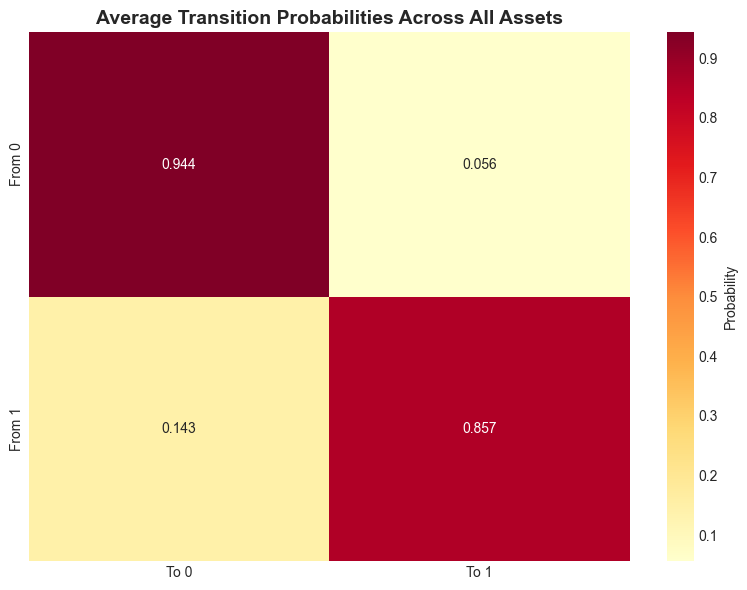

In [62]:
# Heatmap of average transition probabilities
n_msr_regimes = models[list(models.keys())[0]].msr.n_regimes

avg_trans_matrix = np.zeros((n_msr_regimes, n_msr_regimes))

for i in range(n_msr_regimes):
    for j in range(n_msr_regimes):
        col_name = f'Trans_P_{i}_to_{j}'
        avg_trans_matrix[i, j] = metadata_df[col_name].mean()

plt.figure(figsize=(8, 6))
sns.heatmap(avg_trans_matrix, annot=True, fmt='.3f', cmap='YlOrRd', 
            xticklabels=[f'To {i}' for i in range(n_msr_regimes)],
            yticklabels=[f'From {i}' for i in range(n_msr_regimes)],
            cbar_kws={'label': 'Probability'})
plt.title('Average Transition Probabilities Across All Assets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [63]:
# Identify assets with unusual transition probabilities
print("Assets with Unusual Transition Probabilities:")
print("="*80)

# Calculate persistence (diagonal probabilities)
for i in range(n_msr_regimes):
    col_name = f'Trans_P_{i}_to_{i}'
    metadata_df[f'Persistence_{i}'] = metadata_df[col_name]

persistence_cols = [f'Persistence_{i}' for i in range(n_msr_regimes)]

print("\nPersistence Probabilities (P(stay in same regime)):")
display(metadata_df[['Asset'] + persistence_cols].sort_values(persistence_cols[0]))

# Very low persistence (< 0.8)
print("\n\nAssets with LOW PERSISTENCE (<0.8):")
for i, col in enumerate(persistence_cols):
    low_persist = metadata_df[metadata_df[col] < 0.8][['Asset', col]]
    if len(low_persist) > 0:
        print(f"\nRegime {i}:")
        display(low_persist.sort_values(col))

Assets with Unusual Transition Probabilities:

Persistence Probabilities (P(stay in same regime)):


,Asset,Persistence_0,Persistence_1
42,iShares MSCI India ETF,0.4656,0.9943
30,US Dollar,0.4830,0.9982
36,Aluminum Futures,0.4933,0.9929
37,Vanguard Total International Stock ETF,0.5368,0.9940
25,Live Cattle Futures,0.8889,0.5776
21,Sugar,0.9685,0.5413
28,Lumber Futures,0.9695,0.2986
35,Corn Futures,0.9731,0.7151
27,Natural Gas,0.9751,0.8948
24,Silver Futures,0.9760,0.7413




Assets with LOW PERSISTENCE (<0.8):

Regime 0:


,Asset,Persistence_0
42,iShares MSCI India ETF,0.4656
30,US Dollar,0.4830
36,Aluminum Futures,0.4933
37,Vanguard Total International Stock ETF,0.5368



Regime 1:


,Asset,Persistence_1
28,Lumber Futures,0.2986
21,Sugar,0.5413
25,Live Cattle Futures,0.5776
23,Gold Futures,0.5878
29,Coffee,0.6854
33,Soybean Futures,0.6921
1,Consumer Staples Select Sector SPDR,0.7123
35,Corn Futures,0.7151
22,Wheat Futures,0.7276
24,Silver Futures,0.7413


## 9. Return Characteristics by Regime

In [64]:
def calculate_regime_return_characteristics(models: Dict) -> pd.DataFrame:
    """
    Calculate return statistics for each regime across all models.
    
    Parameters:
    -----------
    models : Dict
        Dictionary of loaded KAMA-MSR models
    
    Returns:
    --------
    pd.DataFrame : Return characteristics by regime for all assets
    """
    regime_stats = []
    
    for asset_name, model in models.items():
        try:
            returns = model.returns.dropna()
            regime_labels = model.regime_labels.dropna()
            
            # Align on common index
            common_idx = returns.index.intersection(regime_labels.index)
            returns_aligned = returns.loc[common_idx]
            regime_labels_aligned = regime_labels.loc[common_idx]
            
            for regime in regime_labels_aligned.unique():
                if pd.isna(regime):
                    continue
                
                regime_mask = regime_labels_aligned == regime
                regime_returns = returns_aligned[regime_mask]
                
                if len(regime_returns) > 0:
                    stats = {
                        'Asset': asset_name,
                        'Regime': int(regime),
                        'N_Obs': len(regime_returns),
                        'Mean': regime_returns.mean(),
                        'Std': regime_returns.std(),
                        'Sharpe': regime_returns.mean() / regime_returns.std() * np.sqrt(252) if regime_returns.std() > 0 else 0,
                        'Skewness': skew(regime_returns),
                        'Kurtosis': kurtosis(regime_returns),
                        'Min': regime_returns.min(),
                        'Max': regime_returns.max(),
                        'Pct_Positive': (regime_returns > 0).sum() / len(regime_returns) * 100
                    }
                    
                    regime_stats.append(stats)
        
        except Exception as e:
            print(f"❌ Error calculating return characteristics for {asset_name}: {str(e)}")
    
    return pd.DataFrame(regime_stats)

regime_returns_df = calculate_regime_return_characteristics(models)
regime_returns_df['Mean'] *= 252  # Annualize mean returns
regime_returns_df['Std'] *= np.sqrt(252)  # Annualize std dev

print("Regime Return Characteristics:")
print("="*80)
display(regime_returns_df.groupby('Regime')[['Mean', 'Std', 'Sharpe', 'Skewness', 'Kurtosis']].describe().T\
        .rename(columns={0: 'Low Vol Bull', 1: 'Low Vol Bear', 2: 'High Vol Bull', 3: 'High Vol Bear'}))


Regime Return Characteristics:


Regime          Low Vol Bull  Low Vol Bear  High Vol Bull  High Vol Bear
Mean     count       41.0000       42.0000        40.0000        45.0000
         mean         0.0724       -0.0148        -0.7673        -0.3162
         std          0.0647        0.5614         1.5927         0.8096
         min         -0.1694       -3.5013        -4.6273        -1.7483
         25%          0.0398        0.0138        -1.6929        -0.7332
         50%          0.0796        0.0691        -0.6892        -0.4273
         75%          0.1117        0.1176         0.0225        -0.1403
         max          0.1853        0.3781         4.3454         3.3928
Std      count       41.0000       42.0000        40.0000        45.0000
         mean         0.2060        0.2648         0.5164         0.5963
         std          0.0781        0.1123         0.3198         0.2219
         min          0.1188        0.1514         0.0334         0.0866
         25%          0.1535        0.2153         0.4031         0.5105
         50%          0.1689        0.2344         0.4690         0.5706
         75%          0.2493        0.2610         0.6266         0.6879
         max          0.4043        0.8771         1.8258         1.2128
Sharpe   count       41.0000       42.0000        40.0000        45.0000
         mean         0.4054        0.2218        -1.2784        -0.5101
         std          0.2988        0.8028         5.6378         1.4256
         min         -0.4191       -3.9920       -15.7262        -2.2747
         25%          0.2264        0.0482        -3.3669        -1.1898
         50%          0.4070        0.2832        -1.2630        -0.7827
         75%          0.6256        0.5102         0.1845        -0.2453
         max          0.9029        1.6819        21.3710         6.9323
Skewness count       41.0000       42.0000        40.0000        45.0000
         mean        -0.3704        0.0767        -0.0444         0.1053
         std          0.3249        0.8740         0.5624         0.2703
         min         -1.7899       -2.1423        -2.8124        -0.5778
         25%         -0.4791       -0.0707        -0.2094        -0.0451
         50%         -0.3725        0.0086         0.0000         0.1090
         75%         -0.2402        0.0746         0.2755         0.2706
         max          0.1287        5.0660         0.6817         0.6758
Kurtosis count       41.0000       42.0000        40.0000        45.0000
         mean         2.7785        4.5705         0.3144         0.9474
         std          3.3222       14.2154         2.4685         2.3210
         min          0.8330       -1.6971        -2.0000        -0.9558
         25%          1.4696        0.3030        -0.9679        -0.1044
         50%          2.1513        1.0081        -0.3314         0.4610
         75%          2.6463        2.2708         0.3088         1.1931
         max         21.4797       86.5809         9.7999        11.4853

In [65]:
regime_returns_df.set_index(['Asset', 'Regime']).sort_index()

N_Obs    Mean     Std  Sharpe  Skewness  Kurtosis     Min     Max  Pct_Positive
Asset                      Regime                                                                                 
Aluminum Futures           2         739  0.0132  0.1182  0.1116   -0.0133    2.6793 -0.0319  0.0374       28.6874
                           3         421  0.0378  0.1633  0.2312    0.1452    1.0615 -0.0355  0.0377       45.1306
Brent Crude Oil            0        1670  0.0501  0.2503  0.2001   -0.2191    1.2618 -0.0718  0.0766       49.9401
                           1        1295  0.0456  0.3052  0.1496   -0.1341    1.6856 -0.1029  0.0912       49.6525
                           2           6 -2.6840  0.8235 -3.2591   -0.2340   -0.8157 -0.0896  0.0602       50.0000
...                                  ...     ...     ...     ...       ...       ...     ...     ...           ...
iShares S&P 500 Growth ETF 2           6 -2.9080  0.4454 -6.5287    0.1607   -1.5269 -0.0419  0.0235       33.3333
                           3         289 -0.6168  0.4692 -1.3147    0.2141    0.3968 -0.0967  0.1008       43.5986
iShares S&P 500 Value ETF  0        3186  0.0663  0.1255  0.5282   -0.4636    2.4744 -0.0425  0.0410       54.1117
                           1        1218  0.0826  0.2150  0.3841    0.0033    0.2325 -0.0505  0.0447       51.1494
                           3         248 -0.7119  0.5361 -1.3280    0.0596   -0.0443 -0.0973  0.1017       46.3710

[168 rows x 9 columns]

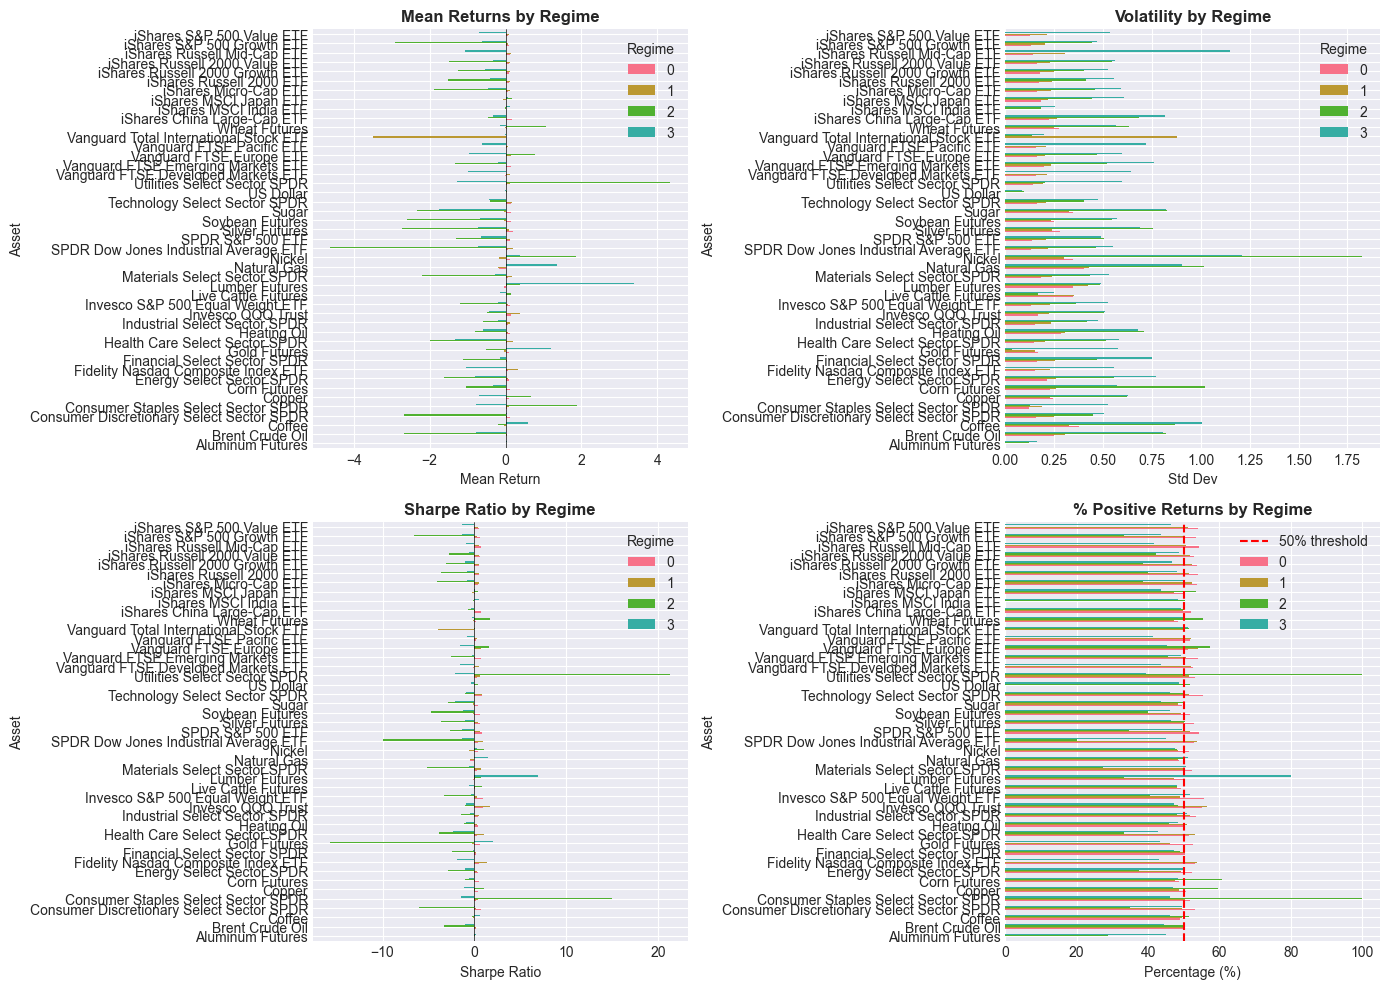

In [66]:
# Compare return characteristics across regimes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mean returns by regime
regime_returns_df.pivot(index='Asset', columns='Regime', values='Mean').plot.barh(ax=axes[0,0])
axes[0,0].set_title('Mean Returns by Regime', fontweight='bold')
axes[0,0].set_xlabel('Mean Return')
axes[0,0].axvline(0, color='black', linestyle='-', linewidth=0.5)

# Volatility by regime
regime_returns_df.pivot(index='Asset', columns='Regime', values='Std').plot.barh(ax=axes[0,1])
axes[0,1].set_title('Volatility by Regime', fontweight='bold')
axes[0,1].set_xlabel('Std Dev')

# Sharpe ratio by regime
regime_returns_df.pivot(index='Asset', columns='Regime', values='Sharpe').plot.barh(ax=axes[1,0])
axes[1,0].set_title('Sharpe Ratio by Regime', fontweight='bold')
axes[1,0].set_xlabel('Sharpe Ratio')
axes[1,0].axvline(0, color='black', linestyle='-', linewidth=0.5)

# Percentage positive by regime
regime_returns_df.pivot(index='Asset', columns='Regime', values='Pct_Positive').plot.barh(ax=axes[1,1])
axes[1,1].set_title('% Positive Returns by Regime', fontweight='bold')
axes[1,1].set_xlabel('Percentage (%)')
axes[1,1].axvline(50, color='red', linestyle='--', label='50% threshold')
axes[1,1].legend()

plt.tight_layout()
plt.show()

In [67]:
# Identify poorly differentiated regimes based on returns
print("Regime Differentiation Analysis:")
print("="*80)

for asset_name in regime_returns_df['Asset'].unique():
    asset_data = regime_returns_df[regime_returns_df['Asset'] == asset_name]
    
    if len(asset_data) >= 2:
        # Check if regimes have similar returns
        mean_diff = abs(asset_data['Mean'].max() - asset_data['Mean'].min())
        std_diff = abs(asset_data['Std'].max() - asset_data['Std'].min())
        
        # Flag if differences are small
        if mean_diff < 0.0005:  # Very small mean difference
            print(f"\n⚠️  {asset_name}: WEAK Mean Differentiation")
            print(f"   Mean difference: {mean_diff:.6f}")
            display(asset_data[['Regime', 'Mean', 'Std', 'Sharpe']])

Regime Differentiation Analysis:


## 10. Model Performance Metrics

In [68]:
def calculate_model_performance_metrics(models: Dict) -> pd.DataFrame:
    """
    Calculate performance metrics for all models.
    
    Parameters:
    -----------
    models : Dict
        Dictionary of loaded KAMA-MSR models
    
    Returns:
    --------
    pd.DataFrame : Performance metrics for all models
    """
    performance_metrics = []
    
    for asset_name, model in models.items():
        try:
            returns = model.returns.dropna()
            regime_labels = model.regime_labels.dropna()
            
            # Align returns and regime_labels on common index
            common_idx = returns.index.intersection(regime_labels.index)
            returns_aligned = returns.loc[common_idx]
            regime_labels_aligned = regime_labels.loc[common_idx]
            
            # Number of parameters
            n_regimes = model.msr.n_regimes
            n_params = n_regimes * 3 + n_regimes * (n_regimes - 1)  # means, stds, betas, transition probs
            
            # Log-likelihood (approximate)
            log_likelihood = 0
            for regime in range(n_regimes):
                regime_mask = regime_labels_aligned == regime
                regime_returns = returns_aligned[regime_mask]
                if len(regime_returns) > 0:
                    ll = -0.5 * len(regime_returns) * np.log(2 * np.pi * model.msr.stds[regime]**2)
                    ll -= np.sum((regime_returns - model.msr.means[regime])**2) / (2 * model.msr.stds[regime]**2)
                    log_likelihood += ll
            
            # AIC and BIC
            n_obs = len(returns_aligned)
            aic = 2 * n_params - 2 * log_likelihood
            bic = n_params * np.log(n_obs) - 2 * log_likelihood
            
            metrics = {
                'Asset': asset_name,
                'Log_Likelihood': log_likelihood,
                'AIC': aic,
                'BIC': bic,
                'N_Params': n_params,
                'N_Obs': n_obs,
                'AIC_per_Obs': aic / n_obs,
                'BIC_per_Obs': bic / n_obs
            }
            
            performance_metrics.append(metrics)
            
        except Exception as e:
            print(f"❌ Error calculating performance metrics for {asset_name}: {str(e)}")
    
    return pd.DataFrame(performance_metrics)

performance_df = calculate_model_performance_metrics(models)

print("Model Performance Metrics:")
print("="*80)
if len(performance_df) > 0:
    display(performance_df.sort_values('BIC'))
else:
    print("❌ No performance metrics calculated")


Model Performance Metrics:


,Asset,Log_Likelihood,AIC,BIC,N_Params,N_Obs,AIC_per_Obs,BIC_per_Obs
12,SPDR S&P 500 ETF,17531.6348,-35047.2696,-34993.6428,8,6023,-5.8189,-5.8100
23,Gold Futures,15872.3833,-31728.7666,-31675.0830,8,6066,-5.2306,-5.2217
11,SPDR Dow Jones Industrial Average ETF,15441.0720,-30866.1441,-30813.6040,8,5258,-5.8703,-5.8603
1,Consumer Staples Select Sector SPDR,14606.3078,-29196.6157,-29144.4526,8,5016,-5.8207,-5.8103
7,Health Care Select Sector SPDR,14370.1413,-28724.2825,-28672.1242,8,5013,-5.7300,-5.7196
39,iShares MSCI Japan ETF,14244.4609,-28472.9218,-28419.7066,8,5721,-4.9769,-4.9676
31,Copper,14073.3166,-28130.6332,-28076.9470,8,6068,-4.6359,-4.6271
20,Industrial Select Sector SPDR,13891.0467,-27766.0934,-27713.9287,8,5017,-5.5344,-5.5240
19,Utilities Select Sector SPDR,13802.7370,-27589.4741,-27537.3062,8,5019,-5.4970,-5.4866
0,Consumer Discretionary Select Sector SPDR,13694.5300,-27373.0601,-27320.8954,8,5017,-5.4561,-5.4457


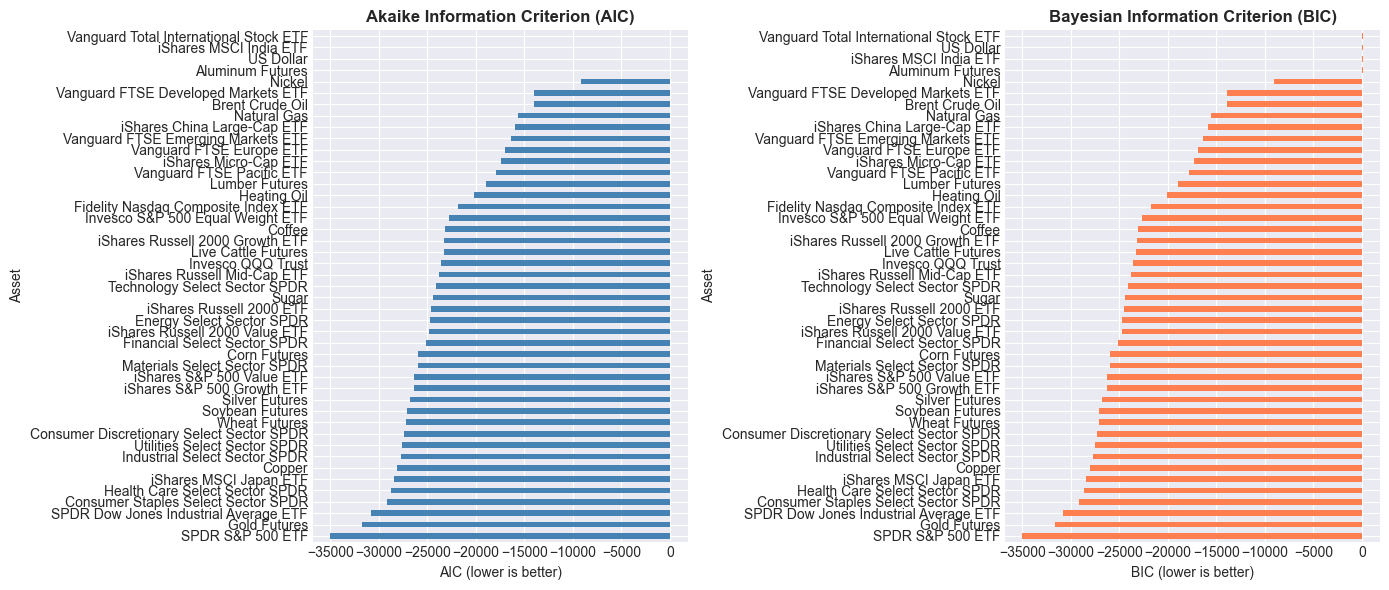


Best Performing Models (by BIC):


,Asset,Log_Likelihood,AIC,BIC
12,SPDR S&P 500 ETF,17531.6348,-35047.2696,-34993.6428
23,Gold Futures,15872.3833,-31728.7666,-31675.0830
11,SPDR Dow Jones Industrial Average ETF,15441.0720,-30866.1441,-30813.6040
1,Consumer Staples Select Sector SPDR,14606.3078,-29196.6157,-29144.4526
7,Health Care Select Sector SPDR,14370.1413,-28724.2825,-28672.1242



Worst Performing Models (by BIC):


,Asset,Log_Likelihood,AIC,BIC
37,Vanguard Total International Stock ETF,-19.6018,55.2036,99.9224
30,US Dollar,0.0000,16.0000,68.0036
42,iShares MSCI India ETF,0.0000,16.0000,59.5633
36,Aluminum Futures,0.0000,16.0000,56.4494
26,Nickel,4567.8940,-9119.7880,-9072.5622


In [69]:
# Visualize performance metrics
if len(performance_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # AIC
    performance_df.sort_values('AIC').plot.barh(x='Asset', y='AIC', ax=axes[0], 
                                                 color='steelblue', legend=False)
    axes[0].set_title('Akaike Information Criterion (AIC)', fontweight='bold')
    axes[0].set_xlabel('AIC (lower is better)')

    # BIC
    performance_df.sort_values('BIC').plot.barh(x='Asset', y='BIC', ax=axes[1], 
                                                 color='coral', legend=False)
    axes[1].set_title('Bayesian Information Criterion (BIC)', fontweight='bold')
    axes[1].set_xlabel('BIC (lower is better)')

    plt.tight_layout()
    plt.show()

    print("\nBest Performing Models (by BIC):")
    display(performance_df.nsmallest(5, 'BIC')[['Asset', 'Log_Likelihood', 'AIC', 'BIC']])

    print("\nWorst Performing Models (by BIC):")
    display(performance_df.nlargest(5, 'BIC')[['Asset', 'Log_Likelihood', 'AIC', 'BIC']])
else:
    print("❌ No performance data to visualize")


## 11. Regime Stability Analysis

In [70]:
# Combine with earlier duration metrics
stability_df = metadata_df[['Asset', 'N_Regime_Changes', 'Avg_Regime_Duration']].merge(
    duration_df[['Asset', 'Pct_Single_Period', 'Std_Duration']], 
    on='Asset'
)

# Add regime change frequency
stability_df['Changes_Per_100_Periods'] = (stability_df['N_Regime_Changes'] / 
                                           metadata_df['N_Data_Points'] * 100)

print("Regime Stability Metrics:")
print("="*80)
display(stability_df.sort_values('Changes_Per_100_Periods', ascending=False))

Regime Stability Metrics:


,Asset,N_Regime_Changes,Avg_Regime_Duration,Pct_Single_Period,Std_Duration,Changes_Per_100_Periods
25,Live Cattle Futures,775,8.9343,6.8299,17.1186,11.1367
38,Vanguard FTSE Europe ETF,121,28.4098,0.0000,25.4921,3.4800
29,Coffee,184,32.4054,3.7838,42.3311,3.0616
36,Aluminum Futures,33,34.1176,0.0000,66.7403,2.8181
27,Natural Gas,125,37.1667,0.7937,46.6876,2.6545
37,Vanguard Total International Stock ETF,47,41.2083,0.0000,51.0543,2.3571
35,Corn Futures,141,42.3944,0.7042,130.2439,2.3387
43,iShares China Large-Cap ETF,67,52.5147,0.0000,62.7224,1.8705
32,Brent Crude Oil,60,52.6885,1.6393,72.2841,1.8570
34,Heating Oil,79,58.5750,0.0000,79.7261,1.6787


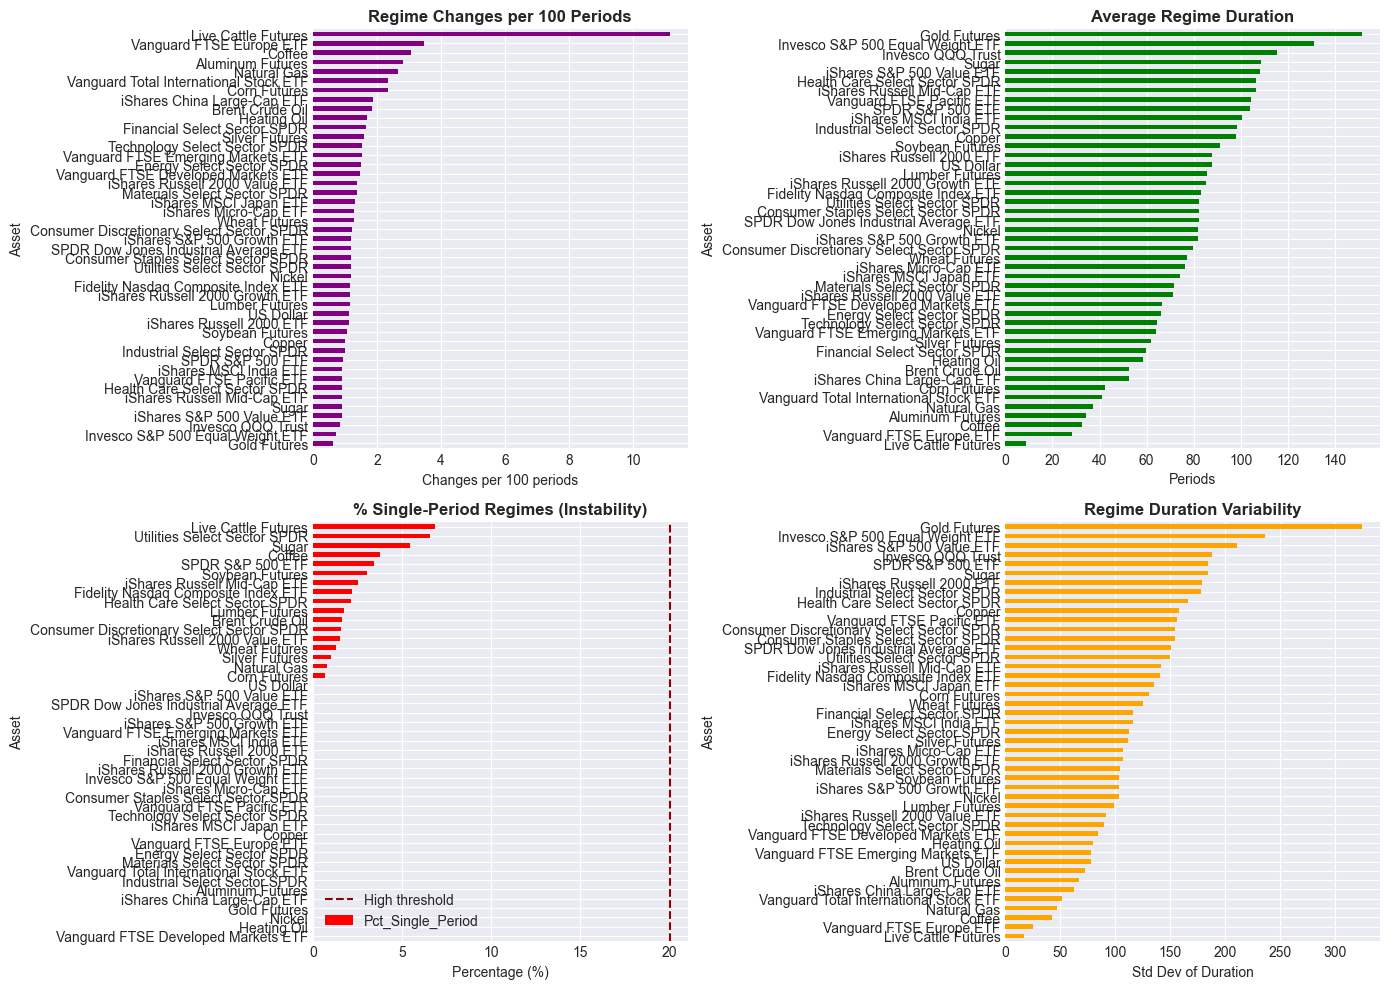

In [71]:
# Visualize stability metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Regime changes per 100 periods
stability_df.sort_values('Changes_Per_100_Periods').plot.barh(
    x='Asset', y='Changes_Per_100_Periods', ax=axes[0,0], color='purple', legend=False
)
axes[0,0].set_title('Regime Changes per 100 Periods', fontweight='bold')
axes[0,0].set_xlabel('Changes per 100 periods')

# Average regime duration
stability_df.sort_values('Avg_Regime_Duration').plot.barh(
    x='Asset', y='Avg_Regime_Duration', ax=axes[0,1], color='green', legend=False
)
axes[0,1].set_title('Average Regime Duration', fontweight='bold')
axes[0,1].set_xlabel('Periods')

# Percentage single-period regimes
stability_df.sort_values('Pct_Single_Period').plot.barh(
    x='Asset', y='Pct_Single_Period', ax=axes[1,0], color='red', legend=False
)
axes[1,0].set_title('% Single-Period Regimes (Instability)', fontweight='bold')
axes[1,0].set_xlabel('Percentage (%)')
axes[1,0].axvline(20, color='darkred', linestyle='--', label='High threshold')
axes[1,0].legend()

# Duration variability
stability_df.sort_values('Std_Duration').plot.barh(
    x='Asset', y='Std_Duration', ax=axes[1,1], color='orange', legend=False
)
axes[1,1].set_title('Regime Duration Variability', fontweight='bold')
axes[1,1].set_xlabel('Std Dev of Duration')

plt.tight_layout()
plt.show()

In [72]:
# Identify unstable models
print("Models with Stability Issues:")
print("="*80)

print("\n1. HIGH REGIME SWITCHING (>15 changes per 100 periods):")
high_switching = stability_df[stability_df['Changes_Per_100_Periods'] > 15].sort_values(
    'Changes_Per_100_Periods', ascending=False
)
if len(high_switching) > 0:
    display(high_switching)
else:
    print("  ✓ None found")

print("\n2. HIGH INSTABILITY (>20% single-period regimes):")
high_instability = stability_df[stability_df['Pct_Single_Period'] > 20].sort_values(
    'Pct_Single_Period', ascending=False
)
if len(high_instability) > 0:
    display(high_instability)
else:
    print("  ✓ None found")

Models with Stability Issues:

1. HIGH REGIME SWITCHING (>15 changes per 100 periods):
  ✓ None found

2. HIGH INSTABILITY (>20% single-period regimes):
  ✓ None found


## 12. Parameter Sensitivity Visualization

In [73]:
# Merge all dataframes for comprehensive analysis
comprehensive_df = metadata_df.merge(duration_df, on='Asset', suffixes=('', '_dur'))
comprehensive_df = comprehensive_df.merge(performance_df, on='Asset')
comprehensive_df = comprehensive_df.merge(stability_df[['Asset', 'Changes_Per_100_Periods']], on='Asset')

print("Comprehensive Dataset Shape:", comprehensive_df.shape)
print("\nFirst few rows:")
display(comprehensive_df.head())

Comprehensive Dataset Shape: (45, 50)

First few rows:


,Asset,N_Data_Points,N_MSR_Regimes,N_Combined_Regimes,KAMA_n,KAMA_n_fast,KAMA_n_slow,Filter_gamma,N_Regime_Changes,Avg_Regime_Duration,Regime_0_Pct,Regime_0_Count,Regime_1_Pct,Regime_1_Count,Regime_2_Pct,Regime_2_Count,Regime_3_Pct,Regime_3_Count,MSR_Mean_0,MSR_Std_0,MSR_Beta_0,MSR_Mean_1,MSR_Std_1,MSR_Beta_1,Trans_P_0_to_0,Trans_P_0_to_1,Trans_P_1_to_0,Trans_P_1_to_1,Mean_Diff,Std_Diff,Regime_Diversity_Score,Persistence_0,Persistence_1,Mean_Duration,Median_Duration,Std_Duration,Min_Duration,Max_Duration,Q25_Duration,Q75_Duration,N_Regimes,Pct_Single_Period,Log_Likelihood,AIC,BIC,N_Params,N_Obs,AIC_per_Obs,BIC_per_Obs,Changes_Per_100_Periods
0,Consumer Discretionary Select Sector SPDR,5038,2,4,20,12,38,1.35,62,79.6349,73.0915,3667,19.0951,958,0.7973,40,7.0161,352,0.0004,0.0129,-0.0052,-0.0008,0.0379,-0.0003,0.9927,0.0073,0.0778,0.9222,0.0012,0.0249,0.4444,0.9927,0.9222,79.6190,25.0,154.2721,1,966,14.00,86.00,63,1.5873,13694.5300,-27373.0601,-27320.8954,8,5017,-5.4561,-5.4457,1.2306
1,Consumer Staples Select Sector SPDR,5038,2,4,21,10,40,0.40,60,82.2295,70.0558,3514,28.8876,1449,0.0598,3,0.9968,50,0.0002,0.0107,-0.0169,-0.0020,0.0584,0.0013,0.9944,0.0056,0.2877,0.7123,0.0021,0.0477,0.5251,0.9944,0.7123,82.2131,30.0,153.9494,2,972,11.00,56.00,61,0.0000,14606.3078,-29196.6157,-29144.4526,8,5016,-5.8207,-5.8103,1.1909
2,iShares Micro-Cap ETF,3367,2,4,15,12,43,0.50,43,76.1591,65.5625,2197,27.5440,923,0.7759,26,6.1176,205,0.0004,0.0142,-0.0012,-0.0028,0.0461,-0.0353,0.9952,0.0048,0.0607,0.9393,0.0031,0.0319,0.3937,0.9952,0.9393,76.1364,31.0,107.2213,5,481,14.75,79.25,44,0.0000,8702.5394,-17389.0789,-17340.1428,8,3351,-5.1892,-5.1746,1.2771
3,Invesco S&P 500 Equal Weight ETF,3946,2,4,14,10,44,1.50,29,131.0333,79.4454,3123,13.4317,528,0.8140,32,6.3088,248,0.0005,0.0118,-0.0033,-0.0018,0.0419,-0.0224,0.9958,0.0042,0.0532,0.9468,0.0023,0.0301,0.5196,0.9958,0.9468,131.0000,36.0,235.8938,3,1066,13.25,161.00,30,0.0000,11393.2586,-22770.5172,-22720.3040,8,3931,-5.7926,-5.7798,0.7349
4,iShares Russell 2000 ETF,4678,2,4,14,12,44,0.85,52,87.9811,69.9121,3260,22.9037,1068,0.7506,35,6.4336,300,0.0004,0.0137,-0.0107,-0.0020,0.0415,-0.0342,0.9954,0.0046,0.0583,0.9417,0.0024,0.0277,0.4222,0.9954,0.9417,87.9623,37.0,178.9587,6,1134,16.00,77.00,53,0.0000,12318.6785,-24621.3570,-24569.7776,8,4663,-5.2802,-5.2691,1.1116


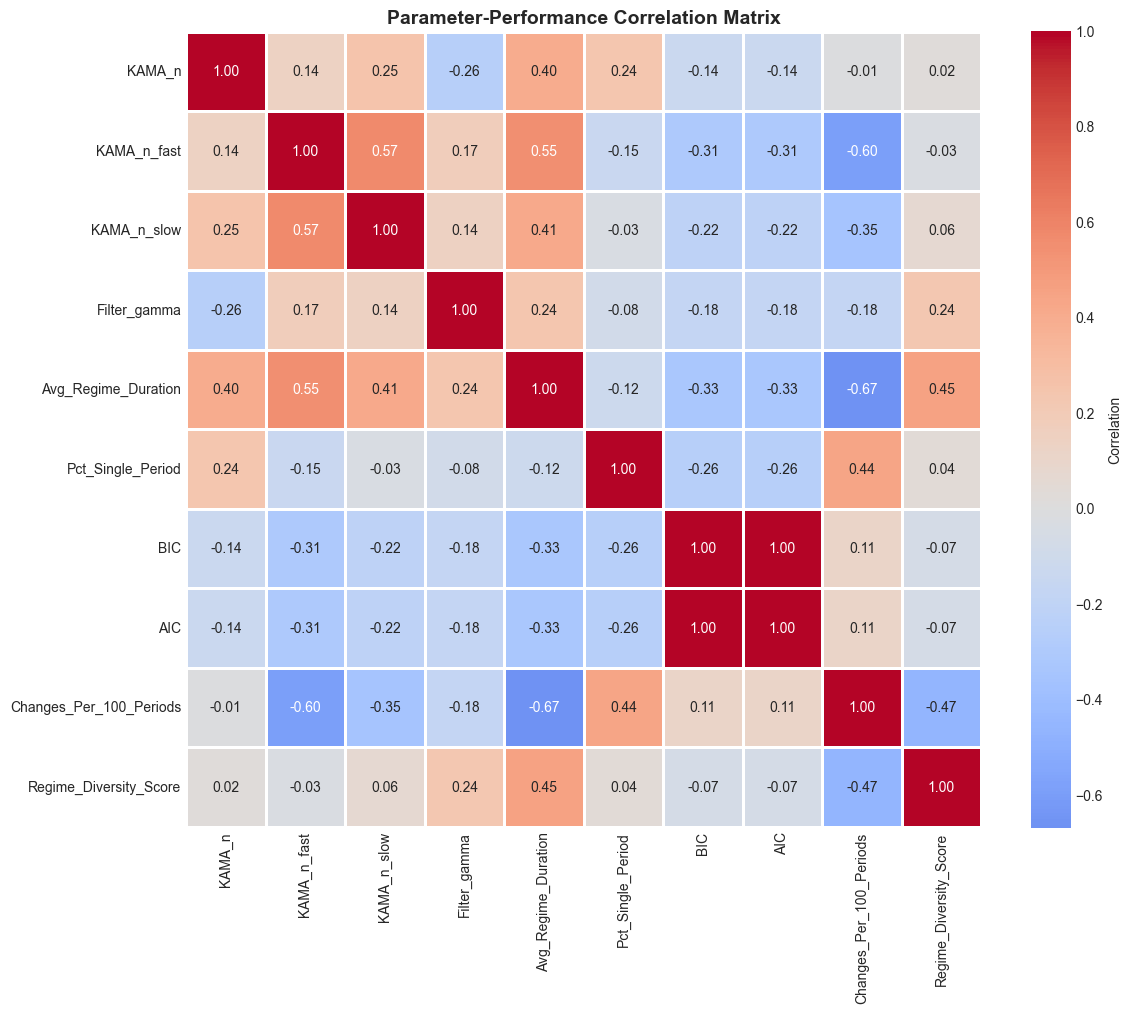


Strongest Correlations with Performance Metrics:

Correlations with BIC (model quality):
  AIC: 1.000
  Avg_Regime_Duration: -0.326
  KAMA_n_fast: -0.311
  Pct_Single_Period: -0.255
  KAMA_n_slow: -0.220


In [74]:
# Correlation matrix of key parameters and performance metrics
key_columns = [
    'KAMA_n', 'KAMA_n_fast', 'KAMA_n_slow', 'Filter_gamma',
    'Avg_Regime_Duration', 'Pct_Single_Period',
    'BIC', 'AIC', 'Changes_Per_100_Periods',
    'Regime_Diversity_Score'
]

# Filter columns that exist
available_cols = [col for col in key_columns if col in comprehensive_df.columns]

correlation_matrix = comprehensive_df[available_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'label': 'Correlation'})
plt.title('Parameter-Performance Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nStrongest Correlations with Performance Metrics:")
print("="*80)

# Find strongest correlations with BIC
if 'BIC' in correlation_matrix.columns:
    bic_corr = correlation_matrix['BIC'].drop('BIC').abs().sort_values(ascending=False)
    print("\nCorrelations with BIC (model quality):")
    for param, corr in bic_corr.head(5).items():
        print(f"  {param}: {correlation_matrix.loc[param, 'BIC']:.3f}")

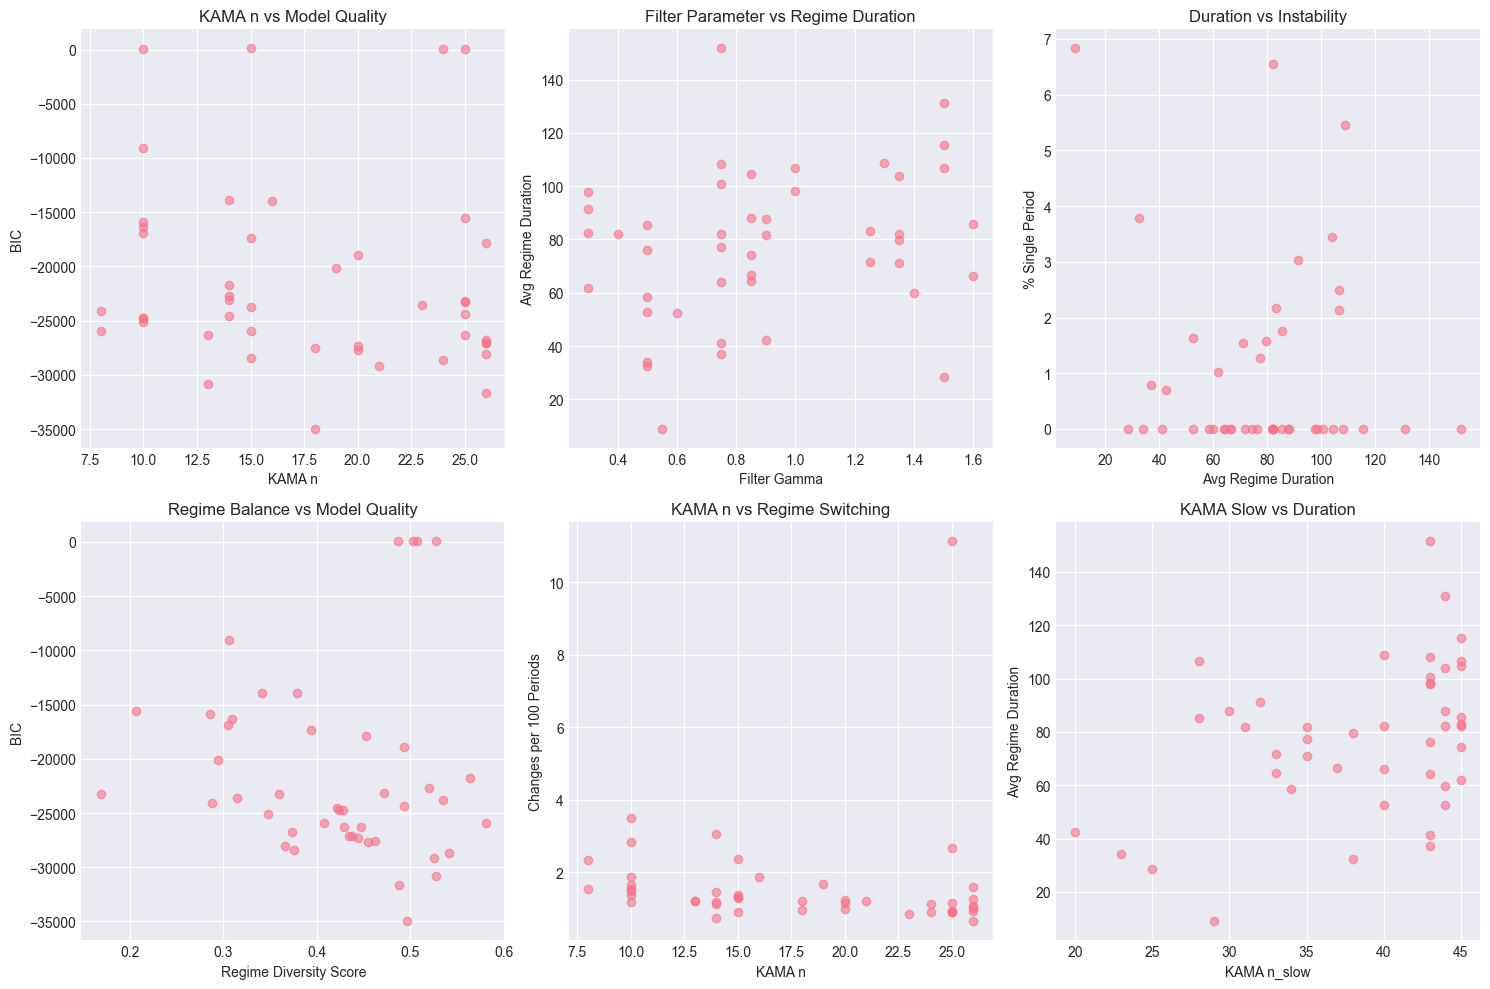

In [75]:
# Scatter plots of key relationships
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# KAMA_n vs BIC
if 'BIC' in comprehensive_df.columns:
    axes[0,0].scatter(comprehensive_df['KAMA_n'], comprehensive_df['BIC'], alpha=0.6)
    axes[0,0].set_xlabel('KAMA n')
    axes[0,0].set_ylabel('BIC')
    axes[0,0].set_title('KAMA n vs Model Quality')

# Filter gamma vs Avg Duration
axes[0,1].scatter(comprehensive_df['Filter_gamma'], comprehensive_df['Avg_Regime_Duration'], alpha=0.6)
axes[0,1].set_xlabel('Filter Gamma')
axes[0,1].set_ylabel('Avg Regime Duration')
axes[0,1].set_title('Filter Parameter vs Regime Duration')

# Avg Duration vs Single Period %
axes[0,2].scatter(comprehensive_df['Avg_Regime_Duration'], comprehensive_df['Pct_Single_Period'], alpha=0.6)
axes[0,2].set_xlabel('Avg Regime Duration')
axes[0,2].set_ylabel('% Single Period')
axes[0,2].set_title('Duration vs Instability')

# Diversity Score vs BIC
if 'BIC' in comprehensive_df.columns and 'Regime_Diversity_Score' in comprehensive_df.columns:
    axes[1,0].scatter(comprehensive_df['Regime_Diversity_Score'], comprehensive_df['BIC'], alpha=0.6)
    axes[1,0].set_xlabel('Regime Diversity Score')
    axes[1,0].set_ylabel('BIC')
    axes[1,0].set_title('Regime Balance vs Model Quality')

# KAMA_n vs Changes per 100
axes[1,1].scatter(comprehensive_df['KAMA_n'], comprehensive_df['Changes_Per_100_Periods'], alpha=0.6)
axes[1,1].set_xlabel('KAMA n')
axes[1,1].set_ylabel('Changes per 100 Periods')
axes[1,1].set_title('KAMA n vs Regime Switching')
# KAMA n_slow vs Avg Duration
axes[1,2].scatter(comprehensive_df['KAMA_n_slow'], comprehensive_df['Avg_Regime_Duration'], alpha=0.6)
axes[1,2].set_xlabel('KAMA n_slow')
axes[1,2].set_ylabel('Avg Regime Duration')
axes[1,2].set_title('KAMA Slow vs Duration')

plt.tight_layout()
plt.show()

## 13. Cross-Asset Regime Correlation

In [76]:
def build_regime_label_matrix(models: Dict) -> pd.DataFrame:
    """
    Build a matrix of regime labels across all assets.
    
    Parameters:
    -----------
    models : Dict
        Dictionary of loaded KAMA-MSR models
    
    Returns:
    --------
    pd.DataFrame : Matrix with dates as index and assets as columns containing regime labels
    """
    regime_data = {}
    
    for asset_name, model in models.items():
        regime_data[asset_name] = model.regime_labels
    
    regime_matrix = pd.DataFrame(regime_data)
    return regime_matrix

regime_matrix = build_regime_label_matrix(models)

print("Regime Label Matrix:")
print("="*80)
print(f"Shape: {regime_matrix.shape}")
print(f"Date range: {regime_matrix.index.min()} to {regime_matrix.index.max()}")
print("\Last few rows:")
display(regime_matrix.tail())

Regime Label Matrix:
Shape: (7363, 45)
Date range: 1995-01-03 00:00:00 to 2019-01-01 00:00:00
\Last few rows:


,Consumer Discretionary Select Sector SPDR,Consumer Staples Select Sector SPDR,iShares Micro-Cap ETF,Invesco S&P 500 Equal Weight ETF,iShares Russell 2000 ETF,Financial Select Sector SPDR,iShares S&P 500 Value ETF,Health Care Select Sector SPDR,iShares Russell 2000 Value ETF,iShares S&P 500 Growth ETF,Invesco QQQ Trust,SPDR Dow Jones Industrial Average ETF,SPDR S&P 500 ETF,iShares Russell 2000 Growth ETF,iShares Russell Mid-Cap ETF,Technology Select Sector SPDR,Fidelity Nasdaq Composite Index ETF,Energy Select Sector SPDR,Materials Select Sector SPDR,Utilities Select Sector SPDR,Industrial Select Sector SPDR,Sugar,Wheat Futures,Gold Futures,Silver Futures,Live Cattle Futures,Nickel,Natural Gas,Lumber Futures,Coffee,US Dollar,Copper,Brent Crude Oil,Soybean Futures,Heating Oil,Corn Futures,Aluminum Futures,Vanguard Total International Stock ETF,Vanguard FTSE Europe ETF,iShares MSCI Japan ETF,Vanguard FTSE Pacific ETF,Vanguard FTSE Emerging Markets ETF,iShares MSCI India ETF,iShares China Large-Cap ETF,Vanguard FTSE Developed Markets ETF
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-12-27,3,1,1,3,1,1,1,0,1,3,3,3,3,1,1,3,3,3,1,0,3,1,1,1,1,0,1,2,1,1,2,1,3,1,1,1,2,3,1,1,1,1,3,1,1
2018-12-28,3,1,1,3,1,1,1,0,1,3,3,3,3,1,1,3,3,3,1,0,3,1,0,1,1,0,1,2,<NA>,1,<NA>,1,3,1,1,1,2,3,1,1,1,1,3,1,1
2018-12-30,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2018-12-31,3,1,1,3,1,1,1,0,1,3,3,3,3,1,1,3,3,3,1,1,3,1,0,1,1,0,1,2,<NA>,1,<NA>,1,3,1,1,1,2,3,1,1,1,1,3,1,1
2019-01-01,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,<NA>,2,1,<NA>,2,<NA>,<NA>,<NA>,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


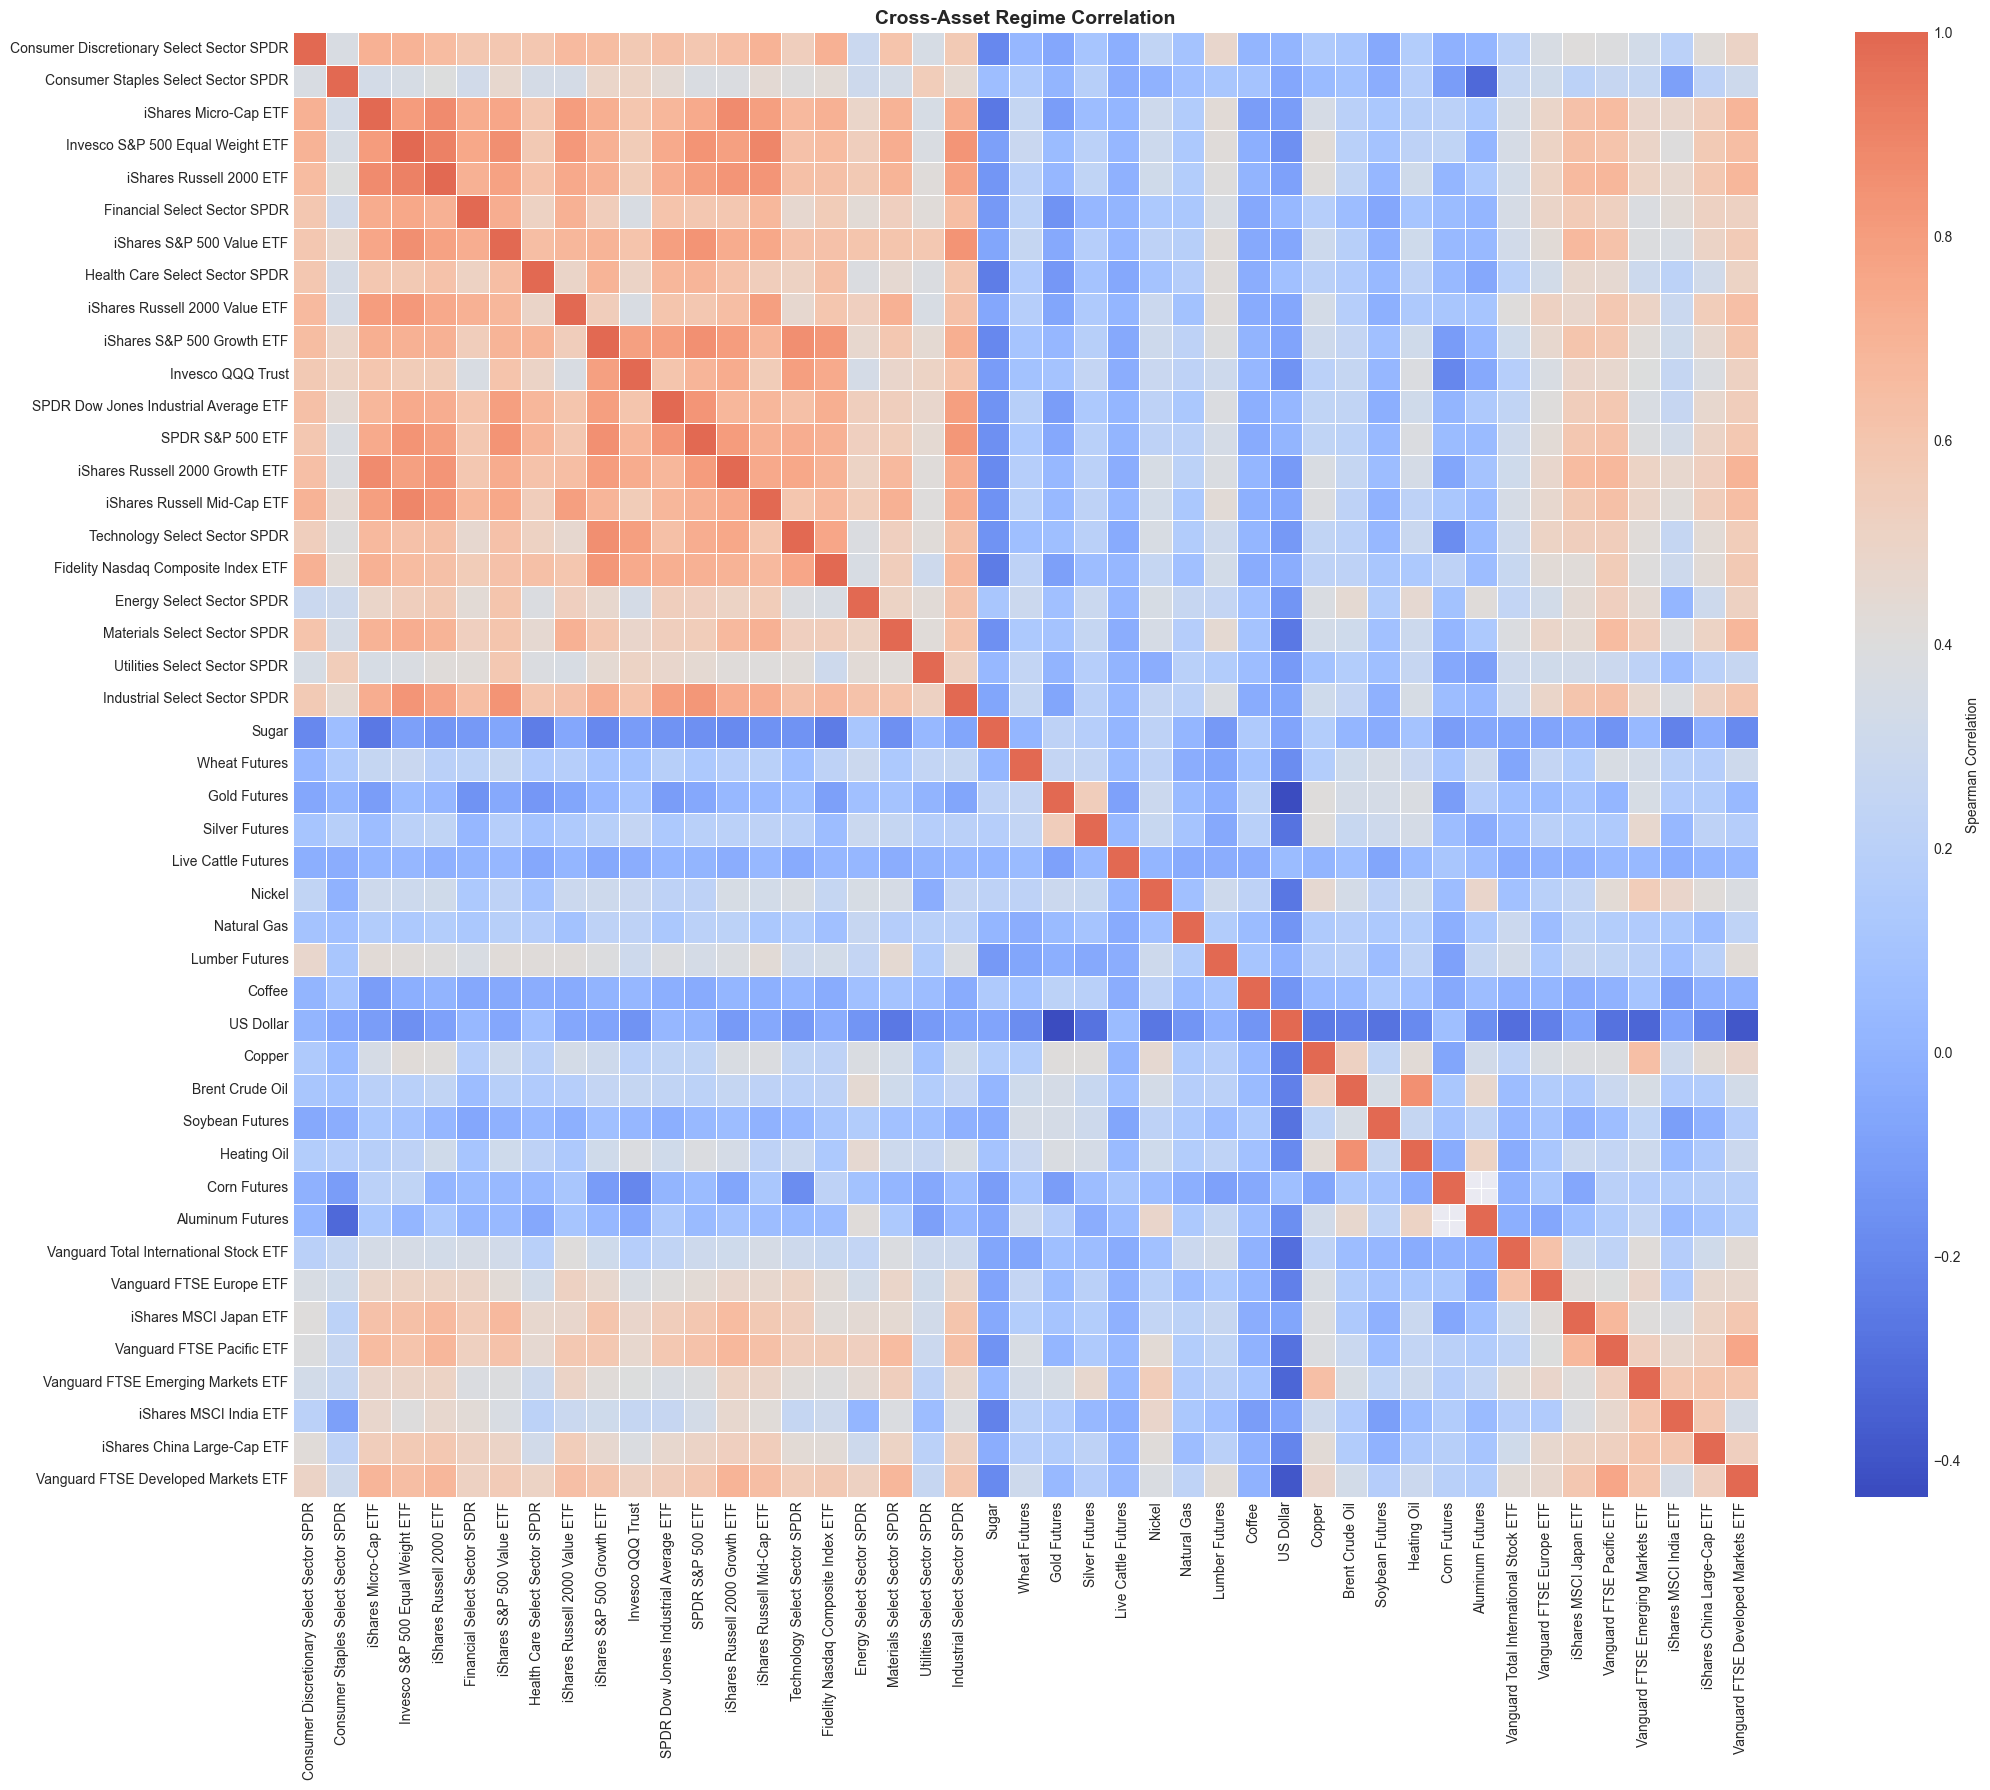


Strongest Cross-Asset Regime Correlations:

Highest Positive Correlations:


,Asset 1,Asset 2,Correlation
9,Invesco S&P 500 Equal Weight ETF,iShares Russell 2000 ETF,0.9081
94,Invesco S&P 500 Equal Weight ETF,iShares Russell Mid-Cap ETF,0.8916
80,iShares Micro-Cap ETF,iShares Russell 2000 Growth ETF,0.8657
8,iShares Micro-Cap ETF,iShares Russell 2000 ETF,0.8656
114,iShares S&P 500 Growth ETF,Technology Select Sector SPDR,0.8597
18,Invesco S&P 500 Equal Weight ETF,iShares S&P 500 Value ETF,0.8550
593,Brent Crude Oil,Heating Oil,0.8532
75,iShares S&P 500 Growth ETF,SPDR S&P 500 ETF,0.8515
72,iShares S&P 500 Value ETF,SPDR S&P 500 ETF,0.8422
69,Invesco S&P 500 Equal Weight ETF,SPDR S&P 500 ETF,0.8409



Highest Negative Correlations:


,Asset 1,Asset 2,Correlation
453,Materials Select Sector SPDR,US Dollar,-0.2564
461,Nickel,US Dollar,-0.2675
558,US Dollar,Soybean Futures,-0.2788
459,Silver Futures,US Dollar,-0.2789
809,US Dollar,Vanguard FTSE Pacific ETF,-0.2876
695,US Dollar,Vanguard Total International Stock ETF,-0.2979
631,Consumer Staples Select Sector SPDR,Aluminum Futures,-0.3174
849,US Dollar,Vanguard FTSE Emerging Markets ETF,-0.3285
975,US Dollar,Vanguard FTSE Developed Markets ETF,-0.3911
458,Gold Futures,US Dollar,-0.4349


In [77]:
# Calculate regime correlation (using aligned dates only)
regime_corr = regime_matrix.corr(method='spearman')  # Spearman for ordinal data

plt.figure(figsize=(max(10, len(models)*0.5), max(8, len(models)*0.4)))
sns.heatmap(regime_corr, annot=False, cmap='coolwarm', center=0.4, 
            square=True, linewidths=0.5, cbar_kws={'label': 'Spearman Correlation'})
plt.title('Cross-Asset Regime Correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nStrongest Cross-Asset Regime Correlations:")
print("="*80)

# Get upper triangle to avoid duplicates
mask = np.triu(np.ones_like(regime_corr, dtype=bool), k=1)
regime_corr_upper = regime_corr.where(mask)

# Find top correlations
correlations = []
for col in regime_corr_upper.columns:
    for idx in regime_corr_upper.index:
        val = regime_corr_upper.loc[idx, col]
        if not pd.isna(val):
            correlations.append({
                'Asset 1': idx,
                'Asset 2': col,
                'Correlation': val
            })

corr_df = pd.DataFrame(correlations).sort_values('Correlation', ascending=False)
print("\nHighest Positive Correlations:")
display(corr_df.head(10))

print("\nHighest Negative Correlations:")
display(corr_df.tail(10))

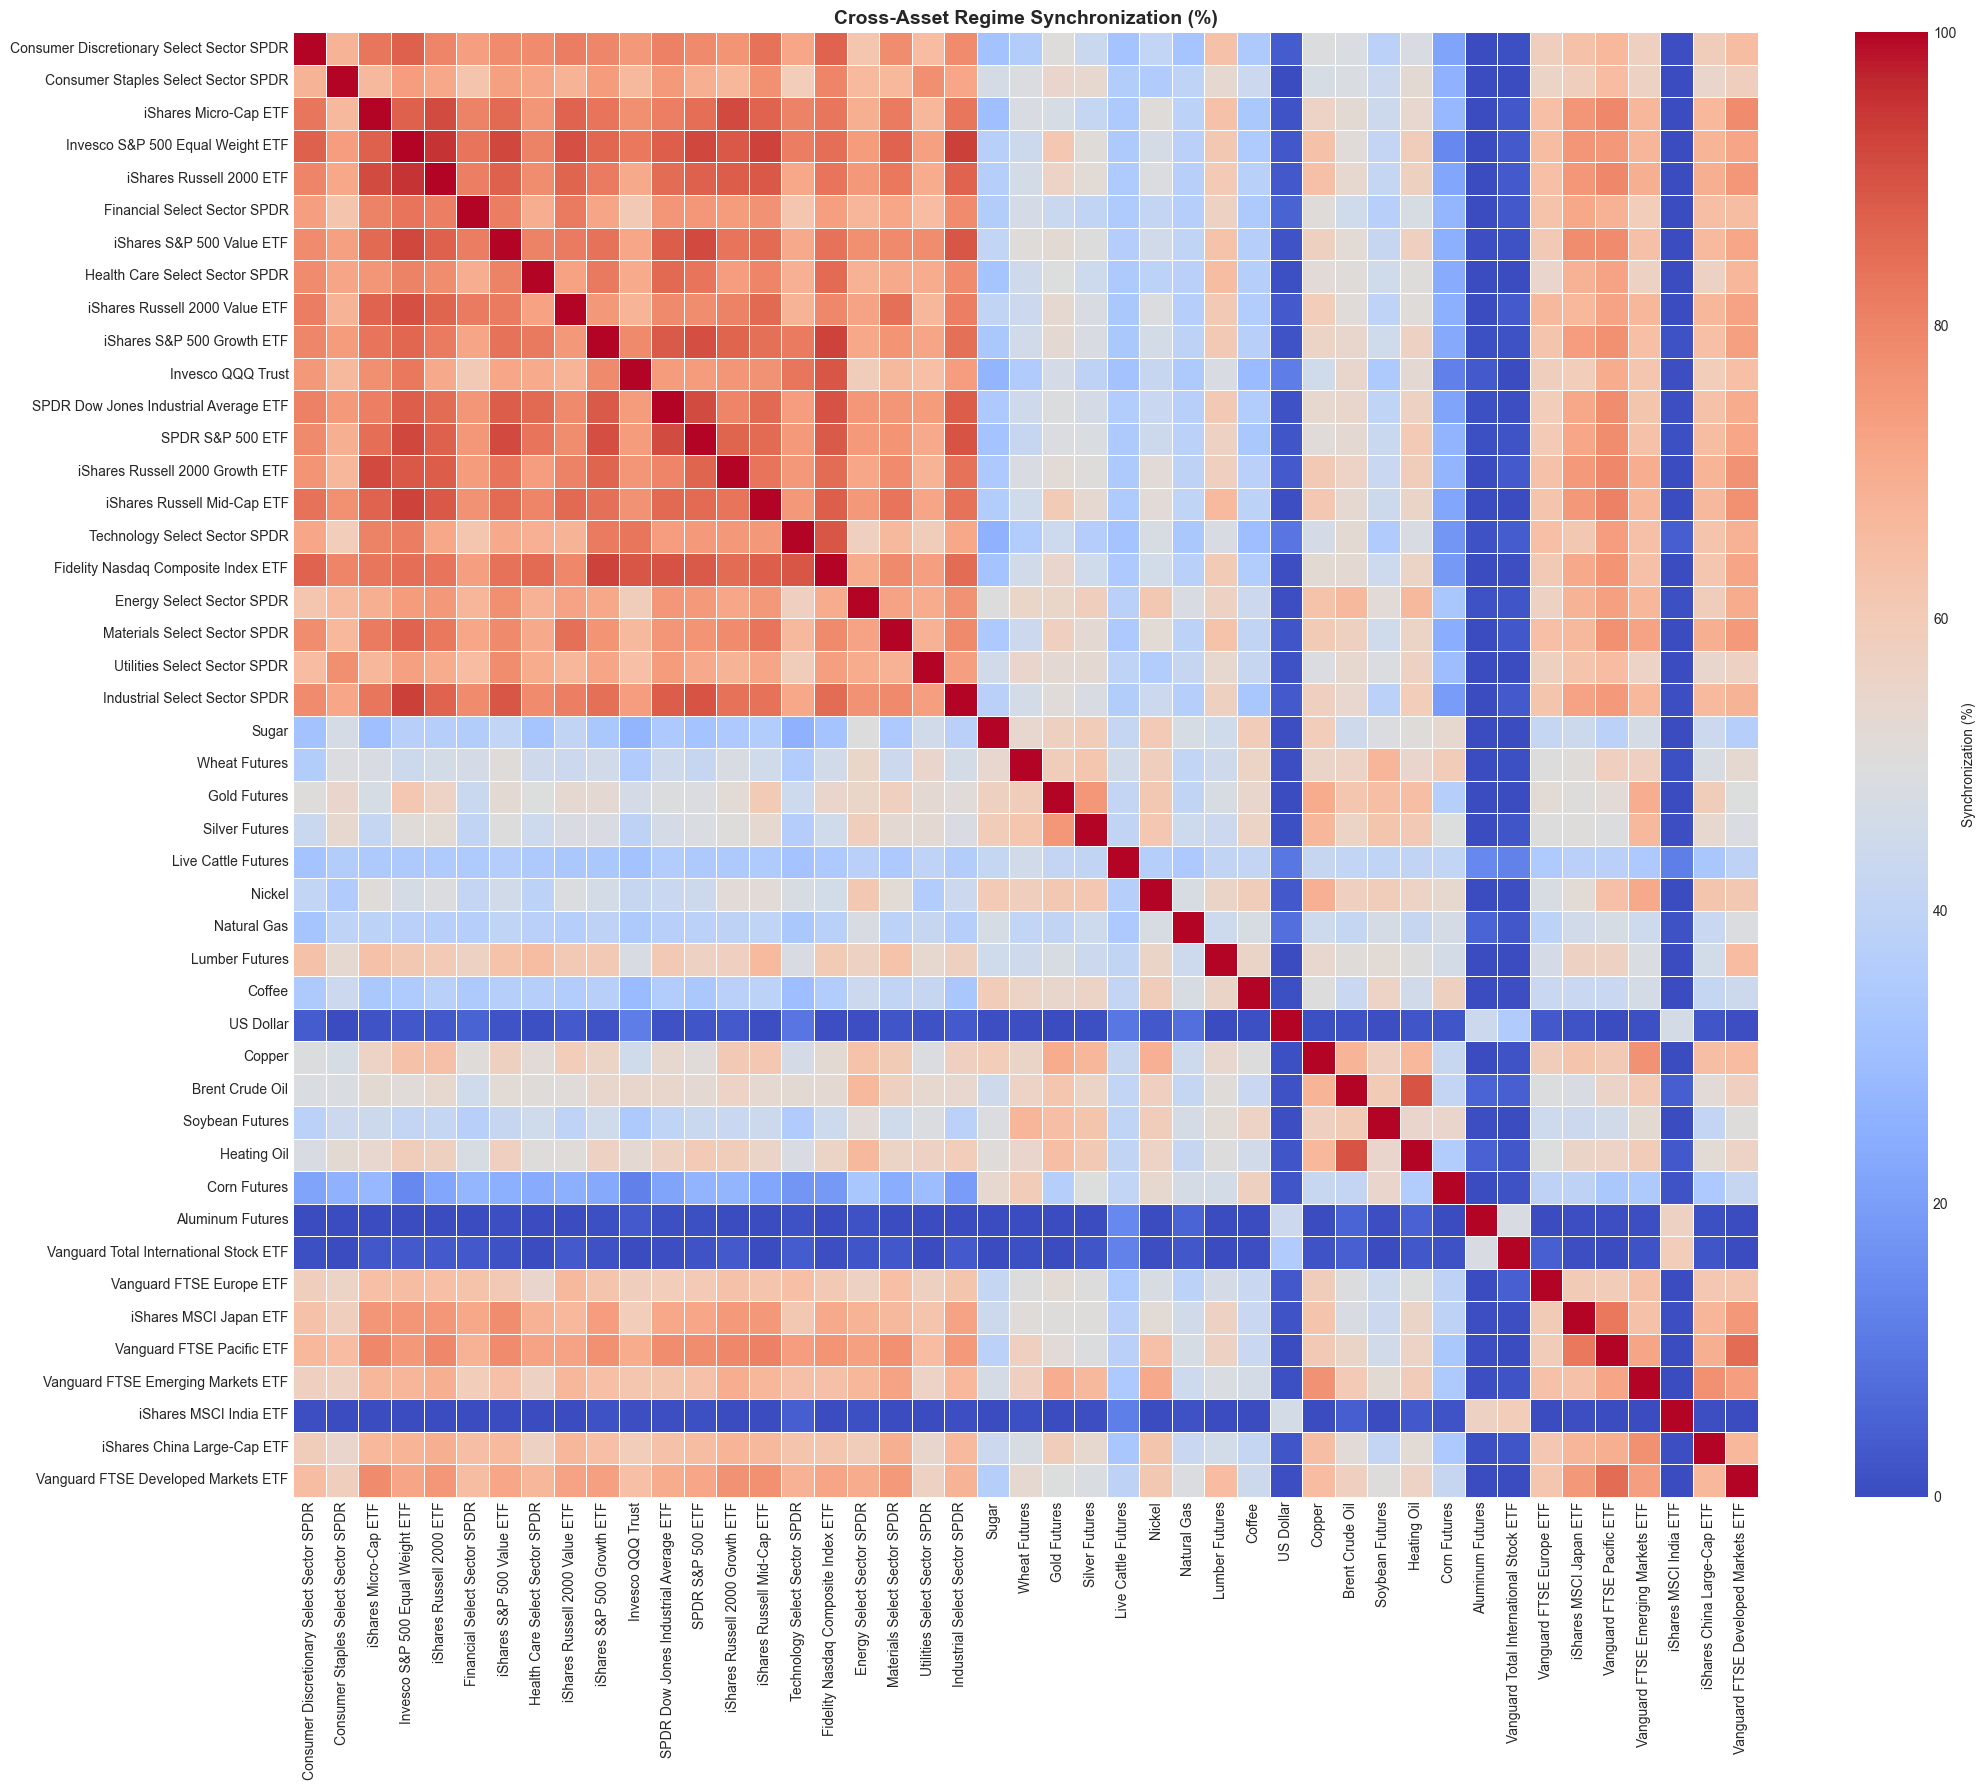


Asset Pairs with Highest Regime Synchronization:


,Asset 1,Asset 2,Sync %
129,Invesco S&P 500 Equal Weight ETF,iShares Russell 2000 ETF,95.0394
145,Invesco S&P 500 Equal Weight ETF,Industrial Select Sector SPDR,93.0552
366,iShares S&P 500 Growth ETF,Fidelity Nasdaq Composite Index ETF,92.7301
139,Invesco S&P 500 Equal Weight ETF,iShares Russell Mid-Cap ETF,92.6227
137,Invesco S&P 500 Equal Weight ETF,SPDR S&P 500 ETF,92.0122
131,Invesco S&P 500 Equal Weight ETF,iShares S&P 500 Value ETF,91.9613
97,iShares Micro-Cap ETF,iShares Russell 2000 Growth ETF,91.7338
254,iShares S&P 500 Value ETF,SPDR S&P 500 ETF,91.6380
88,iShares Micro-Cap ETF,iShares Russell 2000 ETF,91.0474
429,SPDR Dow Jones Industrial Average ETF,SPDR S&P 500 ETF,91.0232



Asset Pairs with Lowest Regime Synchronization:


,Asset 1,Asset 2,Sync %
78,Consumer Staples Select Sector SPDR,Aluminum Futures,0.0
771,Gold Futures,Aluminum Futures,0.0
834,Nickel,iShares MSCI India ETF,0.0
120,iShares Micro-Cap ETF,Aluminum Futures,0.0
546,iShares Russell Mid-Cap ETF,Aluminum Futures,0.0
955,Aluminum Futures,Vanguard FTSE Europe ETF,0.0
909,Copper,iShares MSCI India ETF,0.0
734,Sugar,iShares MSCI India ETF,0.0
35,Consumer Discretionary Select Sector SPDR,Aluminum Futures,0.0
687,Utilities Select Sector SPDR,iShares MSCI India ETF,0.0


In [78]:
# Calculate regime synchronization percentage
def calculate_regime_sync(regime_matrix: pd.DataFrame) -> pd.DataFrame:
    """Calculate percentage of time assets are in the same regime."""
    assets = regime_matrix.columns
    n_assets = len(assets)
    
    sync_matrix = pd.DataFrame(index=assets, columns=assets, dtype=float)
    
    for i, asset1 in enumerate(assets):
        for j, asset2 in enumerate(assets):
            if i == j:
                sync_matrix.loc[asset1, asset2] = 100.0
            else:
                # Find common dates
                common_dates = regime_matrix[[asset1, asset2]].dropna().index
                if len(common_dates) > 0:
                    same_regime = (regime_matrix.loc[common_dates, asset1] == 
                                  regime_matrix.loc[common_dates, asset2])
                    sync_matrix.loc[asset1, asset2] = same_regime.sum() / len(common_dates) * 100
    
    return sync_matrix.astype(float)

sync_matrix = calculate_regime_sync(regime_matrix)

plt.figure(figsize=(max(10, len(models)*0.5), max(8, len(models)*0.4)))
sns.heatmap(sync_matrix, annot=False, fmt='.1f', cmap='coolwarm', 
            vmin=0, vmax=100, square=True, linewidths=0.5,
            cbar_kws={'label': 'Synchronization (%)'})
plt.title('Cross-Asset Regime Synchronization (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Convert to long format
sync_data = []
for i, asset1 in enumerate(sync_matrix.index):
    for j, asset2 in enumerate(sync_matrix.columns):
        if i < j:  # Upper triangle only
            sync_data.append({
                'Asset 1': asset1,
                'Asset 2': asset2,
                'Sync %': sync_matrix.loc[asset1, asset2]
            })

sync_df = pd.DataFrame(sync_data).sort_values('Sync %', ascending=False)

print("\nAsset Pairs with Highest Regime Synchronization:")
print("="*80)
display(sync_df.head(10))

print("\nAsset Pairs with Lowest Regime Synchronization:")
print("="*80)
display(sync_df.tail(10).sort_values('Sync %'))

## 14. Identify Outliers and Anomalies

In [79]:
def identify_outliers_zscore(df: pd.DataFrame, columns: list, threshold: float = 3.0) -> pd.DataFrame:
    """
    Identify outliers using z-score method.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Data to analyze
    columns : list
        Columns to check for outliers
    threshold : float
        Z-score threshold (default: 3.0)
    
    Returns:
    --------
    pd.DataFrame : Rows with outlier values
    """
    outliers = pd.DataFrame()
    
    for col in columns:
        if col in df.columns:
            z_scores = np.abs(stats.zscore(df[col].dropna()))
            col_outliers = df[z_scores > threshold]
            
            if len(col_outliers) > 0:
                col_outliers['Outlier_Column'] = col
                col_outliers['Z_Score'] = z_scores[z_scores > threshold]
                outliers = pd.concat([outliers, col_outliers])
    
    return outliers

# Define columns to check
outlier_check_columns = [
    'KAMA_n', 'KAMA_n_fast', 'KAMA_n_slow', 'Filter_gamma',
    'Avg_Regime_Duration', 'Pct_Single_Period',
    'BIC', 'Changes_Per_100_Periods',
    'Regime_Diversity_Score'
]

# Filter available columns
available_outlier_cols = [col for col in outlier_check_columns if col in comprehensive_df.columns]

outliers = identify_outliers_zscore(comprehensive_df, available_outlier_cols, threshold=2.5)

print("Outlier Analysis (Z-score > 2.5):")
print("="*80)

if len(outliers) > 0:
    outlier_summary = outliers.groupby('Asset')['Outlier_Column'].apply(list).reset_index()
    outlier_summary.columns = ['Asset', 'Outlier Parameters']
    display(outlier_summary)
    
    print("\nDetailed Outlier Information:")
    display(outliers[['Asset', 'Outlier_Column', 'Z_Score']].sort_values('Z_Score', ascending=False))
else:
    print("✓ No significant outliers found")

Outlier Analysis (Z-score > 2.5):


,Asset,Outlier Parameters
0,Aluminum Futures,[BIC]
1,Corn Futures,[KAMA_n_slow]
2,Gold Futures,[Avg_Regime_Duration]
3,Live Cattle Futures,"[Pct_Single_Period, Changes_Per_100_Periods, R..."
4,Sugar,[Pct_Single_Period]
5,US Dollar,[BIC]
6,Utilities Select Sector SPDR,[Pct_Single_Period]
7,Vanguard Total International Stock ETF,[BIC]
8,iShares MSCI India ETF,[BIC]



Detailed Outlier Information:


,Asset,Outlier_Column,Z_Score
25,Live Cattle Futures,Changes_Per_100_Periods,6.0915
25,Live Cattle Futures,Pct_Single_Period,3.3224
19,Utilities Select Sector SPDR,Pct_Single_Period,3.1663
35,Corn Futures,KAMA_n_slow,2.7312
25,Live Cattle Futures,Regime_Diversity_Score,2.6644
23,Gold Futures,Avg_Regime_Duration,2.6609
37,Vanguard Total International Stock ETF,BIC,2.5459
30,US Dollar,BIC,2.5421
42,iShares MSCI India ETF,BIC,2.5411
36,Aluminum Futures,BIC,2.5407


In [80]:
# IQR-based outlier detection
def identify_outliers_iqr(df: pd.DataFrame, columns: list, multiplier: float = 1.5) -> pd.DataFrame:
    """
    Identify outliers using IQR method.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Data to analyze
    columns : list
        Columns to check for outliers
    multiplier : float
        IQR multiplier (default: 1.5)
    
    Returns:
    --------
    pd.DataFrame : Rows with outlier values
    """
    outliers = pd.DataFrame()
    
    for col in columns:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            
            lower_bound = Q1 - multiplier * IQR
            upper_bound = Q3 + multiplier * IQR
            
            col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].copy()
            
            if len(col_outliers) > 0:
                col_outliers['Outlier_Column'] = col
                col_outliers['Outlier_Value'] = col_outliers[col]
                col_outliers['Lower_Bound'] = lower_bound
                col_outliers['Upper_Bound'] = upper_bound
                outliers = pd.concat([outliers, col_outliers])
    
    return outliers

iqr_outliers = identify_outliers_iqr(comprehensive_df, available_outlier_cols, multiplier=1.5)

print("\nOutlier Analysis (IQR method):")
print("="*80)

if len(iqr_outliers) > 0:
    iqr_summary = iqr_outliers.groupby('Asset')['Outlier_Column'].apply(list).reset_index()
    iqr_summary.columns = ['Asset', 'Outlier Parameters']
    display(iqr_summary)
else:
    print("✓ No significant outliers found")


Outlier Analysis (IQR method):


,Asset,Outlier Parameters
0,Aluminum Futures,"[KAMA_n_fast, BIC, Changes_Per_100_Periods]"
1,Coffee,"[KAMA_n_fast, Changes_Per_100_Periods]"
2,Corn Futures,[KAMA_n_fast]
3,Live Cattle Futures,"[KAMA_n_fast, Pct_Single_Period, Changes_Per_1..."
4,Natural Gas,[Changes_Per_100_Periods]
5,Sugar,[Pct_Single_Period]
6,US Dollar,"[KAMA_n_fast, BIC]"
7,Utilities Select Sector SPDR,[Pct_Single_Period]
8,Vanguard FTSE Europe ETF,"[KAMA_n_fast, Changes_Per_100_Periods]"
9,Vanguard Total International Stock ETF,"[KAMA_n_fast, BIC]"


In [81]:
# Identify problematic models based on multiple criteria
def flag_problematic_models(df: pd.DataFrame) -> pd.DataFrame:
    """
    Flag models with multiple potential issues.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Comprehensive model data
    
    Returns:
    --------
    pd.DataFrame : Models with flags and issue counts
    """
    issues = df[['Asset']].copy()
    
    # Flag various issues
    issues['High_Instability'] = df['Pct_Single_Period'] > 20
    issues['Low_Differentiation'] = df['Regime_Diversity_Score'] > 0.6 if 'Regime_Diversity_Score' in df.columns else False
    issues['Short_Duration'] = df['Avg_Regime_Duration'] < 5
    issues['High_Switching'] = df['Changes_Per_100_Periods'] > 15
    issues['Poor_BIC'] = df['BIC'] > df['BIC'].quantile(0.75) if 'BIC' in df.columns else False
    
    # Count issues
    issue_cols = [col for col in issues.columns if col != 'Asset']
    issues['Total_Issues'] = issues[issue_cols].sum(axis=1)
    
    return issues.sort_values('Total_Issues', ascending=False)

problem_flags = flag_problematic_models(comprehensive_df)

print("Models Flagged for Potential Issues:")
print("="*80)

problem_models = problem_flags[problem_flags['Total_Issues'] > 0]
display(problem_models)

print(f"\n{len(problem_models)} out of {len(comprehensive_df)} models flagged with issues")

Models Flagged for Potential Issues:


,Asset,High_Instability,Low_Differentiation,Short_Duration,High_Switching,Poor_BIC,Total_Issues
44,Vanguard FTSE Developed Markets ETF,False,False,False,False,True,1
30,US Dollar,False,False,False,False,True,1
43,iShares China Large-Cap ETF,False,False,False,False,True,1
42,iShares MSCI India ETF,False,False,False,False,True,1
41,Vanguard FTSE Emerging Markets ETF,False,False,False,False,True,1
26,Nickel,False,False,False,False,True,1
38,Vanguard FTSE Europe ETF,False,False,False,False,True,1
37,Vanguard Total International Stock ETF,False,False,False,False,True,1
36,Aluminum Futures,False,False,False,False,True,1
27,Natural Gas,False,False,False,False,True,1



11 out of 45 models flagged with issues


## 15. Generate Improvement Recommendations

In [82]:
def generate_improvement_recommendations(
    metadata_df: pd.DataFrame,
    duration_df: pd.DataFrame,
    performance_df: pd.DataFrame,
    stability_df: pd.DataFrame,
    problem_flags: pd.DataFrame,
    regime_returns_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Generate comprehensive improvement recommendations based on all analyses.
    
    Parameters:
    -----------
    metadata_df, duration_df, performance_df, stability_df, problem_flags, regime_returns_df
        Analysis dataframes
    
    Returns:
    --------
    pd.DataFrame : Recommendations for each asset with priority scores
    """
    recommendations = []
    
    for asset in metadata_df['Asset'].unique():
        asset_recs = {'Asset': asset, 'Recommendations': [], 'Priority': 0}
        
        # Check problem flags
        asset_flags = problem_flags[problem_flags['Asset'] == asset]
        if len(asset_flags) > 0:
            flags = asset_flags.iloc[0]
            
            if flags.get('High_Instability', False):
                asset_recs['Recommendations'].append("⚠️  HIGH INSTABILITY: Increase filter gamma or KAMA n to reduce single-period regimes")
                asset_recs['Priority'] += 3
            
            if flags.get('Low_Differentiation', False):
                asset_recs['Recommendations'].append("⚠️  LOW REGIME DIFFERENTIATION: Consider increasing MSR regimes or revising KAMA parameters")
                asset_recs['Priority'] += 2
            
            if flags.get('Short_Duration', False):
                asset_recs['Recommendations'].append("⚠️  SHORT REGIME DURATION: Increase minimum regime duration filter")
                asset_recs['Priority'] += 2
            
            if flags.get('High_Switching', False):
                asset_recs['Recommendations'].append("⚠️  HIGH SWITCHING FREQUENCY: Adjust KAMA sensitivity (increase n or n_slow)")
                asset_recs['Priority'] += 2
            
            if flags.get('Poor_BIC', False):
                asset_recs['Recommendations'].append("⚠️  POOR MODEL FIT: Review parameter choices or consider alternative regime count")
                asset_recs['Priority'] += 1
        
        # Check regime returns
        asset_regime_returns = regime_returns_df[regime_returns_df['Asset'] == asset]
        if len(asset_regime_returns) >= 2:
            mean_diff = abs(asset_regime_returns['Mean'].max() - asset_regime_returns['Mean'].min())
            if mean_diff < 0.01:  # Very small annualized return difference
                asset_recs['Recommendations'].append("💡 WEAK REGIME SEPARATION: Regimes show similar returns; verify KAMA trend detection")
                asset_recs['Priority'] += 2
        
        # KAMA parameter checks
        asset_meta = metadata_df[metadata_df['Asset'] == asset].iloc[0]
        if asset_meta['KAMA_n'] < 10:
            asset_recs['Recommendations'].append("💡 KAMA EFFICIENCY PERIOD TOO SHORT: May be too sensitive to noise")
            asset_recs['Priority'] += 1
        
        if asset_meta['KAMA_n_slow'] > 100:
            asset_recs['Recommendations'].append("💡 KAMA SLOW PERIOD VERY HIGH: May miss important regime shifts")
            asset_recs['Priority'] += 1
        
        # Duration variability
        asset_dur = duration_df[duration_df['Asset'] == asset].iloc[0]
        if asset_dur['Std_Duration'] > asset_dur['Mean_Duration']:
            asset_recs['Recommendations'].append("💡 HIGH DURATION VARIABILITY: Consider tightening minimum duration constraints")
            asset_recs['Priority'] += 1
        
        # Add positive notes
        if asset_recs['Priority'] == 0:
            asset_recs['Recommendations'].append("✅ Model appears well-calibrated with no major issues detected")
        
        recommendations.append(asset_recs)
    
    recs_df = pd.DataFrame(recommendations)
    recs_df['N_Issues'] = recs_df['Recommendations'].apply(lambda x: len([r for r in x if '⚠️' in r or '💡' in r]))
    
    return recs_df.sort_values('Priority', ascending=False)

# Generate recommendations
if len(performance_df) > 0 and len(problem_flags) > 0:
    recommendations_df = generate_improvement_recommendations(
        metadata_df, duration_df, performance_df, stability_df, problem_flags, regime_returns_df
    )

    print("="*80)
    print("MODEL IMPROVEMENT RECOMMENDATIONS")
    print("="*80)
    print("\nPriority levels: Higher = More urgent\n")

    for _, row in recommendations_df.iterrows():
        print(f"\n{'='*80}")
        print(f"ASSET: {row['Asset']}")
        print(f"Priority Score: {row['Priority']} | Issues Found: {row['N_Issues']}")
        print(f"{'-'*80}")
        for rec in row['Recommendations']:
            print(f"  {rec}")
    
    print(f"\n{'='*80}")
    print(f"SUMMARY: {len(recommendations_df[recommendations_df['Priority'] > 0])} assets need attention")
    print(f"{'='*80}\n")
    
    # Export recommendations
    recommendations_export = recommendations_df.copy()
    recommendations_export['Recommendations'] = recommendations_export['Recommendations'].apply(lambda x: ' | '.join(x))
    
    print("\nRecommendations Summary Table:")
    display(recommendations_export[['Asset', 'Priority', 'N_Issues', 'Recommendations']])
else:
    print("❌ Cannot generate recommendations - missing required data")


MODEL IMPROVEMENT RECOMMENDATIONS

Priority levels: Higher = More urgent


ASSET: Vanguard FTSE Developed Markets ETF
Priority Score: 2 | Issues Found: 2
--------------------------------------------------------------------------------
  ⚠️  POOR MODEL FIT: Review parameter choices or consider alternative regime count
  💡 HIGH DURATION VARIABILITY: Consider tightening minimum duration constraints

ASSET: Technology Select Sector SPDR
Priority Score: 2 | Issues Found: 2
--------------------------------------------------------------------------------
  💡 KAMA EFFICIENCY PERIOD TOO SHORT: May be too sensitive to noise
  💡 HIGH DURATION VARIABILITY: Consider tightening minimum duration constraints

ASSET: iShares China Large-Cap ETF
Priority Score: 2 | Issues Found: 2
--------------------------------------------------------------------------------
  ⚠️  POOR MODEL FIT: Review parameter choices or consider alternative regime count
  💡 HIGH DURATION VARIABILITY: Consider tightening minimum du

,Asset,Priority,N_Issues,Recommendations
44,Vanguard FTSE Developed Markets ETF,2,2,⚠️ POOR MODEL FIT: Review parameter choices o...
15,Technology Select Sector SPDR,2,2,💡 KAMA EFFICIENCY PERIOD TOO SHORT: May be too...
43,iShares China Large-Cap ETF,2,2,⚠️ POOR MODEL FIT: Review parameter choices o...
42,iShares MSCI India ETF,2,2,⚠️ POOR MODEL FIT: Review parameter choices o...
41,Vanguard FTSE Emerging Markets ETF,2,2,⚠️ POOR MODEL FIT: Review parameter choices o...
26,Nickel,2,2,⚠️ POOR MODEL FIT: Review parameter choices o...
27,Natural Gas,2,2,⚠️ POOR MODEL FIT: Review parameter choices o...
37,Vanguard Total International Stock ETF,2,2,⚠️ POOR MODEL FIT: Review parameter choices o...
36,Aluminum Futures,2,2,⚠️ POOR MODEL FIT: Review parameter choices o...
35,Corn Futures,2,2,💡 KAMA EFFICIENCY PERIOD TOO SHORT: May be too...
